#  Evaluation Framework (Complete)
## Accuracy, Context/Relevancy, and Usefulness Evaluation

This notebook implements your  evaluation framework with the following dimensions:
- **Accuracy**: No hallucination and correct representation of provided facts
- **Context/Relevancy**: For lay users and ML experts (with/without XAI)
- **User Usefulness**: Prediction quality assessment and accuracy judgment

Supports G-Eval, LLM-Eval, and Ranking evaluation methods.

**Final Updates:**
- G-Eval works with both GPT (logprobs) and DeepSeek (traditional scores)
- Context building excludes XAI when none, includes SARIMAX table
- Ranking runs with both judges and has clear best-to-worst ordering
- Comprehensive summary and analysis sections
- Fixed ranking implementation for both judges

In [2]:
# === CONFIGURATION SECTION ===
import pandas as pd
import numpy as np
import json
import time
import random
import math
import tiktoken
import re
from typing import Dict, List, Any, Tuple, Optional
from dataclasses import dataclass
from pathlib import Path
import openai
from langchain_azure_ai.chat_models import AzureAIChatCompletionsModel
from datetime import datetime

# === USER CONFIGURATION ===
# Set these paths according to your setup
CSV_INPUT_PATH = "./../explanations/"  # Path where CSV files are located
EVALUATION_OUTPUT_PATH = "forsetzung_results/"    # Path where evaluation results will be saved

# Sampling configuration
SAMPLE_CONFIG = {
    "mode": "all",  # Options: "per_strategy", "fixed_total", "all"
    "sample_size": 5,       # For "per_strategy" or "fixed_total" modes
    "random_seed": 42
}

# Few-shot examples (leave empty list if not using)
FEW_SHOT_EXAMPLES = []  # Add examples here when ready

# Configuration - Easy to modify
CONFIG = {
    # API settings
    "SLEEP_BETWEEN_CALLS": 0.5,
    "MAX_RETRIES": 3,

    # LLM configurations
    "GPT_CONFIG": {
        "azure_endpoint": "https://fabian.openai.azure.com/",
        "api_key": "95914996539f4ec0a2d0d2ec8d16aee3",
        "api_version": "2024-10-21",
        "deployment_name": "gpt-4o",
        "temperature": 0.0,
    },

    "DEEPSEEK_CONFIG": {
        "endpoint": "https://DeepSeek-R1-quevd.westus3.models.ai.azure.com",
        "credential": "SyqFMJQjC9aA3cwgWFSjEWXILVVheZl5",
        "model_name": "DeepSeek-R1-quevd",
        "temperature": 0.0,
    }
}

# Set random seeds
random.seed(SAMPLE_CONFIG["random_seed"])
np.random.seed(SAMPLE_CONFIG["random_seed"])

# Create output directory
Path(EVALUATION_OUTPUT_PATH).mkdir(parents=True, exist_ok=True)

print(f"Configuration loaded.")
print(f"CSV Input Path: {CSV_INPUT_PATH}")
print(f"Evaluation Output Path: {EVALUATION_OUTPUT_PATH}")
print(f"Sample Mode: {SAMPLE_CONFIG['mode']}, Size: {SAMPLE_CONFIG['sample_size']}")
print(f"Few-shot examples: {len(FEW_SHOT_EXAMPLES)}")

Configuration loaded.
CSV Input Path: ./../explanations/
Evaluation Output Path: forsetzung_results/
Sample Mode: all, Size: 5
Few-shot examples: 0


In [3]:
# === LOAD PROMPTS ===
# Import prompts from the  framework

# G-Eval prompts (separate for each dimension)
ACCURACY_PROMPT = """
You are evaluating the ACCURACY of a time-series forecast explanation.

Context: Time series data with single-step ahead prediction of weekly global active power in kWh.

Evaluation Criteria:
ACCURACY (1-5): No hallucination and correct representation of provided facts.
- 5: All provided information is accurately represented (numerical values, feature names, relationships, metrics)
- 4: Minor inaccuracies in non-critical details but core provided facts are correct
- 3: Some factual errors in representing provided data but main message intact
- 2: Multiple factual errors that misrepresent the provided information
- 1: Major hallucinations or significant misrepresentation of provided data

Chain of Thought Evaluation Steps:
1. Identify what information was actually provided in the context
2. Check if mentioned numerical values match the provided data
3. Verify that any referenced feature names and values are correctly stated
4. Confirm that any mentioned model performance metrics are accurately reported
5. Assess if relationships described are factually correct based on provided information
6. Rate overall factual accuracy of representing the PROVIDED information only

**Important**: Do not penalize explanations for missing information if none was provided in the context. Only evaluate accuracy of what information was actually given.

Please think through each step, **then on a new line output only**

SCORE: <1-5>
"""

LAY_USER_RELEVANCY_PROMPT = """
You are a NON-TECHNICAL USER evaluating a forecast explanation.

You have NO background in machine learning, statistics, or technical methods. You just want to understand why the system made this prediction and whether you should trust it.

Evaluation Criteria:
RELEVANCY (1-5): How relevant and useful is this explanation for your decision-making needs?
- 5: Extremely relevant and helpful for understanding and trusting the prediction
- 4: Very relevant with useful information for my needs
- 3: Somewhat relevant but could be more helpful
- 2: Limited relevance to what I need to know
- 1: Not relevant or confusing for a non-technical user

Chain of Thought Evaluation Steps:
1. Does this explanation help me understand WHY the prediction was made?
2. Can I determine if I should trust this prediction based on the explanation?
3. Is the information presented in a way I can understand?
4. Does this give me actionable insights for my decision-making?
5. Rate overall relevancy for a lay user

Please think through each step, **then on a new line output only**

SCORE: <1-5>
"""

EXPERT_RELEVANCY_PROMPT = """
You are a MACHINE LEARNING EXPERT evaluating a forecast explanation.

You have deep knowledge of machine learning models and time-series forecasting methods.

Evaluation Criteria:
RELEVANCY (1-5): How relevant is this explanation for technical understanding and model assessment?
- 5: Extremely relevant with appropriate technical depth for the information provided
- 4: Very relevant with good technical information
- 3: Somewhat relevant but missing some key technical aspects
- 2: Limited technical relevance
- 1: Not technically relevant or misleading

Chain of Thought Evaluation Steps:
1. Does the explanation provide sufficient technical reasoning given the available information?
2. Can I assess model behavior and prediction reliability from this explanation?
3. Is the technical content accurate and well-presented?
4. Does this meet the needs of an expert given what information is available?
5. Rate overall technical relevancy

Please think through each step, **then on a new line output only**

SCORE: <1-5>
"""

# USEFULNESS_PROMPT = """
# You are a NON-TECHNICAL USER evaluating how useful a forecast explanation is for understanding prediction quality.
#
# You have NO background in machine learning or statistics. You just want to know if you should trust this prediction.
#
# Context: Time series forecast with prediction value and explanation provided.
#
# Task: Based ONLY on the explanation, how close do you think the predicted value is to the true value?
#
# Choose one option (percentage error can be positive or negative):
# 1. Very close (within ±10% error)
# 2. Close (±10% to ±20% error)
# 3. Somewhat off (±20% to ±30% error)
# 4. Far off (more than ±30% error)
# 5. Don't know / Cannot determine from explanation
#
# Rate how well the explanation helps you make this judgment (1-5):
# - 5: Explanation makes it very clear how accurate the prediction is
# - 4: Explanation gives good guidance about prediction accuracy
# - 3: Explanation provides some helpful information
# - 2: Explanation gives limited guidance about accuracy
# - 1: Explanation doesn't help assess prediction accuracy at all
#
# Return ONLY a JSON object:
# {
#   "accuracy_assessment": 1, 2, 3, 4, or 5,
#   "explanation_helpfulness": <1-5>,
#   "reasoning": "Brief explanation of how you made this assessment"
# }
# """

USEFULNESS_PREDICTION_CLOSENESS_PROMPT = """
You are a NON-TECHNICAL USER evaluating how close a forecast prediction is to the true value.

You have NO background in machine learning or statistics. You just want to know if the predicted value is likely to be close to the actual outcome.

Context: Time series forecast with prediction value and explanation provided.

Evaluation Criteria:
PREDICTION CLOSENESS (1-5): How close is the predicted value to the true value, based ONLY on the explanation?
- 1: Very close (within ±10% error)
- 2: Close (±10% to ±20% error)
- 3: Somewhat off (±20% to ±30% error)
- 4: Far off (more than ±30% error)
- 5: Don't know / Cannot determine from the explanation

Chain of Thought Evaluation Steps:
1. Identify any signals in the explanation that indicate expected error or confidence (e.g., past errors, uncertainty ranges, stability/volatility cues).
2. Check whether concrete comparisons or references (e.g., “similar to last week,” “seasonal pattern,” “MAE≈X%”) support an error estimate.
3. Translate those cues into an approximate percentage error band.
4. If the explanation lacks sufficient information to estimate closeness, choose 5 (Don't know).
5. Assign a score using the 1–5 scale above.

Please think through each step, **then on a new line output only**

SCORE: <1-5>
"""

USEFULNESS_EXPLANATION_HELPFULNESS_PROMPT = """
You are a NON-TECHNICAL USER evaluating how useful a forecast explanation is for judging prediction accuracy.

You have NO background in machine learning or statistics. You just want to know if the explanation gives you enough information to decide how close the prediction is to the true value.

Evaluation Criteria:
HELPFULNESS (1-5): How well does the explanation help you judge prediction accuracy?
- 5: Makes it very clear how accurate the prediction is
- 4: Gives good guidance about prediction accuracy
- 3: Provides some helpful information
- 2: Gives limited guidance
- 1: Does not help assess accuracy at all

Chain of Thought Evaluation Steps:
1. Check clarity: Is the explanation understandable for a lay user (plain language, concrete references)?
2. Check evidence: Does it include cues that inform accuracy (e.g., recent error rates, uncertainty ranges, comparison to history/seasonality, drivers affecting reliability)?
3. Check actionability: Can a lay user form a reasonable judgment about closeness from the information given?
4. Penalize jargon-only or vague statements that do not improve judgment.
5. Assign a score using the 1–5 scale above.

Please think through each step, **then on a new line output only**

SCORE: <1-5>
"""

# LLM-Eval unified prompt
LLM_EVAL_PROMPT = """
You are evaluating time-series forecast explanations using multiple evaluation criteria.

Context: Time series data with single-step ahead prediction of weekly global active power in kWh.

Evaluate the explanation on these dimensions and return ONLY a JSON object:

Dimensions:
- accuracy: No hallucination and correct representation of provided facts (1-5)
- lay_user_relevancy: Relevancy and usefulness for non-technical users (1-5)
- expert_relevancy: Relevancy for technical understanding and model assessment (1-5)
- usefulness_helpfulness: How well the explanation helps assess prediction quality (1-5)
- usefulness_assessment: Prediction accuracy judgment (1=very close, 2=close, 3=somewhat off, 4=far off, 5=don't know)

Scoring: 1=poor, 2=below average, 3=average, 4=good, 5=excellent

Return format:
{
  "accuracy": <1-5>,
  "lay_user_relevancy": <1-5>,
  "expert_relevancy": <1-5>,
  "usefulness_helpfulness": <1-5>,
  "usefulness_assessment": <1-5>,
  "justification": "Brief rationale for scores"
}
"""

# Ranking prompt
RANKING_PROMPT = """
You are comparing multiple explanations for the same time-series forecast prediction.

Context: Time series data with single-step ahead prediction of weekly global active power in kWh.

Task: Rank the explanations from BEST to WORST based on overall quality considering:
- Accuracy: No hallucination and correct representation of provided facts
- Lay User Relevancy: Usefulness for non-technical users
- Expert Relevancy: Technical depth and model assessment value
- Usefulness: Ability to help users assess prediction quality

The explanations are labeled as A, B, C, etc.

IMPORTANT: List the explanations in order from BEST (first position) to WORST (last position).

Return ONLY a JSON object with:
{
  "ranking": ["A", "B", "C", ...],
  "justification": "Brief explanation of ranking rationale focusing on the four evaluation criteria"
}
"""

print("Prompts loaded successfully")

Prompts loaded successfully


In [4]:
# === TOKEN TRACKING UTILITIES ===

def count_tokens(text: str, model: str = "gpt-4o") -> int:
    """Count tokens in text using tiktoken"""
    try:
        if "gpt-4" in model.lower():
            encoding = tiktoken.encoding_for_model("gpt-4")
        else:
            encoding = tiktoken.get_encoding("cl100k_base")
        return len(encoding.encode(text))
    except Exception:
        # Fallback estimation
        return int(len(text.split()) * 1.3)

def extract_tokens_from_response(response) -> Dict[str, int]:
    """Extract token usage from API response"""
    tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    
    try:
        if hasattr(response, 'usage') and response.usage:
            tokens["prompt_tokens"] = response.usage.prompt_tokens
            tokens["completion_tokens"] = response.usage.completion_tokens
            tokens["total_tokens"] = response.usage.total_tokens
        elif hasattr(response, 'response_metadata') and 'token_usage' in response.response_metadata:
            usage = response.response_metadata['token_usage']
            tokens["prompt_tokens"] = usage.get('prompt_tokens', 0)
            tokens["completion_tokens"] = usage.get('completion_tokens', 0)
            tokens["total_tokens"] = usage.get('total_tokens', 0)
    except Exception as e:
        print(f"Warning: Could not extract token usage: {e}")
    
    return tokens

print("Token tracking utilities loaded")

Token tracking utilities loaded


In [5]:
# === UPDATED CONTEXT BUILDING ===

def build_context(row: pd.Series) -> str:
    """Build the prompt/context string for a single dataframe row."""
    # --- 1. Parse the dict‑ish columns safely -------------------------------
    feature_vals = row.get("Feature_vals", {})
    xai_vals     = row.get("XAI_vals",   {})

    for name, val in (("feature_vals", feature_vals), ("xai_vals", xai_vals)):
        if isinstance(val, str):
            try:
                if name == "feature_vals":
                    feature_vals = json.loads(val)
                else:
                    xai_vals = json.loads(val)
            except json.JSONDecodeError:
                if name == "feature_vals":
                    feature_vals = {}
                else:
                    xai_vals = {}

    # --- 2. Core scalar metrics --------------------------------------------
    parts = [
        f"Prediction={row.get('Prediction', 'N/A')}",
        f"Model={row.get('Model', 'N/A')}",
        f"FeatureValues={json.dumps(feature_vals)}",
    ]

    # Add XAI block only if XAI column is NOT the literal string 'none'
    if str(row.get("XAI", "none")).lower() != "none":
        parts.extend([
            f"XAI={row.get('XAI')}",
            f"BaseValue={row.get('XAI_base_value', 'N/A')}",
            f"XAIValues={json.dumps(xai_vals)}",
        ])

    parts.extend([
        f"MAE={row.get('MAE', 'N/A')}",
        f"RMSE={row.get('RMSE', 'N/A')}",
        f"R2={row.get('R2', 'N/A')}",
    ])

    context = "; ".join(parts)

    # --- 3. Tack on SARIMAX results table if applicable ---------------------
    if str(row.get("Model", "")).upper().startswith("SARIMAX") and row.get("HumanMsg"):
        # everything from the first "SARIMAX Results" header downwards
        m = re.search(r"(SARIMAX Results.*)", row["HumanMsg"], flags=re.DOTALL)
        sarimax_block = m.group(1) if m else row["HumanMsg"]
        context += f"\n\n[SARIMAX results table]\n{sarimax_block}"

    return context

print("Updated context building function loaded")

Updated context building function loaded


In [6]:
# === DATA LOADING AND SAMPLING ===

def load_and_sample_data() -> pd.DataFrame:
    """Load CSV files and create sample based on configuration"""
    
    # Load all strategy files
    strategy_files = [
        "cot_few_shot.csv", "cot_zero_shot.csv", "few_shot.csv",
        "meta_prompting.csv", "reflexion.csv", "role_based.csv",
        "self_consistency.csv", "zero_shot.csv"
    ]
    
    frames = []
    for file in strategy_files:
        path = Path(CSV_INPUT_PATH) / file
        if path.exists():
            df = pd.read_csv(path)
            df["Strategy"] = file.replace(".csv", "")
            frames.append(df)
        else:
            print(f"Warning: {file} not found")
    
    if not frames:
        raise FileNotFoundError("No CSV files found")
    
    # Combine all data
    df_all = pd.concat(frames, ignore_index=True)
    print(f"Total rows loaded: {len(df_all)}")
    
    # Apply sampling based on configuration
    if SAMPLE_CONFIG["mode"] == "all":
        df_sample = df_all.copy()
        print("Using ALL data")
    
    elif SAMPLE_CONFIG["mode"] == "per_strategy":
        # Sample N rows per strategy
        strategies = df_all["Strategy"].unique()
        samples_per_strategy = SAMPLE_CONFIG["sample_size"]
        
        sampled_parts = []
        for strategy in strategies:
            strategy_data = df_all[df_all["Strategy"] == strategy]
            n_samples = min(samples_per_strategy, len(strategy_data))
            sampled_parts.append(strategy_data.sample(n_samples, random_state=SAMPLE_CONFIG["random_seed"]))
        
        df_sample = pd.concat(sampled_parts, ignore_index=True)
        print(f"Sampled {samples_per_strategy} rows per strategy")
    
    elif SAMPLE_CONFIG["mode"] == "fixed_total":
        # Sample fixed total number of rows
        total_sample_size = SAMPLE_CONFIG["sample_size"]
        if total_sample_size >= len(df_all):
            df_sample = df_all.copy()
        else:
            df_sample = df_all.sample(total_sample_size, random_state=SAMPLE_CONFIG["random_seed"])
        print(f"Sampled {len(df_sample)} total rows")
    
    print(f"Final sample size: {len(df_sample)}")
    print(f"Strategies represented: {df_sample['Strategy'].value_counts().to_dict()}")
    
    return df_sample.reset_index(drop=True)

def build_ranking_sets(n_sets: int = 1, use_all_sets: bool = False) -> List[pd.DataFrame]:
    """Build sets for ranking evaluation - each set contains one instance per strategy"""

    strategy_files = [
        "cot_few_shot.csv", "cot_zero_shot.csv", "few_shot.csv",
        "meta_prompting.csv", "reflexion.csv", "role_based.csv",
        "self_consistency.csv", "zero_shot.csv"
    ]

    # Load all data
    frames = []
    for file in strategy_files:
        path = Path(CSV_INPUT_PATH) / file
        if path.exists():
            df = pd.read_csv(path)
            df["Strategy"] = file.replace(".csv", "")
            frames.append(df)

    df_all = pd.concat(frames, ignore_index=True)
    all_strategies = sorted(df_all["Strategy"].unique())
    n_strategies = len(all_strategies)

    # Find instances that exist in all strategies
    id_cols = ["LLM", "Model", "XAI", "WeekEndDate", "Prediction"]
    id_counts = (
        df_all
        .groupby(id_cols)["Strategy"]
        .nunique()
        .reset_index(name="strategy_count")
    )
    full_ids = id_counts[id_counts["strategy_count"] == n_strategies]

    if full_ids.empty:
        raise ValueError("No forecast instance is present in every strategy file!")

    # Sample N forecast instances or use all
    if use_all_sets:
        sampled_ids = full_ids[id_cols]
        print(f"Using all {len(sampled_ids)} available ranking sets")
    else:
        sampled_ids = full_ids.sample(
            n=min(n_sets, len(full_ids)),
            random_state=SAMPLE_CONFIG["random_seed"]
        )[id_cols]
        print(f"Sampled {len(sampled_ids)} ranking sets")

    # Build sets
    sets = []
    for _, id_vals in sampled_ids.iterrows():
        mask = (df_all[id_cols] == id_vals.values).all(axis=1)
        one_set = df_all.loc[mask].drop_duplicates(id_cols + ["Strategy"]).copy()

        # Randomize row order to avoid positional bias
        one_set = one_set.sample(frac=1, random_state=random.randint(0, 1_000_000)).reset_index(drop=True)
        sets.append(one_set)

    print(f"Built {len(sets)} ranking sets; each has {n_strategies} rows (one per strategy)")
    return sets


print("Data loading functions ready")

Data loading functions ready


In [7]:
# Load sample data
df_sample = load_and_sample_data()
print("\nSample data loaded successfully")
df_sample.head()

Total rows loaded: 660
Using ALL data
Final sample size: 660
Strategies represented: {'meta_prompting': 90, 'few_shot': 90, 'role_based': 90, 'reflexion': 90, 'self_consistency': 90, 'zero_shot': 90, 'cot_few_shot': 60, 'cot_zero_shot': 60}

Sample data loaded successfully


,LLM,Temperature,SampleID,RowPos,Model,XAI,WeekEndDate,Prediction,TrueValue,PctError,...,Explanation,XAI_base_value,Feature_vals,XAI_vals,Strategy,TokensDrafts,TokensCritic,GraderJSON,TokensSynth,CandidatesJSON
0,GPT,<default>,1,4,XGB,none,2009-11-09,175.442017,208.200983,-15.734300,...,• XGB uses the **last week’s energy** (lag 1=1...,<none>,"{""lag_1"": 184.72663333333333, ""lag_2"": 216.379...",<none>,cot_few_shot,NaN,NaN,NaN,NaN,NaN
1,GPT,<default>,1,4,XGB,shap,2009-11-09,175.442017,208.200983,-15.734300,...,• **Baseline prediction** from SHAP is ≈ 177 k...,177.36563110351562,"{""lag_1"": 184.72663333333333, ""lag_2"": 216.379...","{""lag_1"": -11.753593444824219, ""lag_2"": 3.3634...",cot_few_shot,NaN,NaN,NaN,NaN,NaN
2,GPT,<default>,1,4,XGB,lime,2009-11-09,175.442017,208.200983,-15.734300,...,• The starting point or **baseline** predictio...,168.3533153083382,"{""lag_1"": 184.72663333333333, ""lag_2"": 216.379...","{""lag_1"": 20.577108089606064, ""lag_2"": -1.4232...",cot_few_shot,NaN,NaN,NaN,NaN,NaN
3,GPT,<default>,1,28,XGB,none,2010-04-26,176.144424,169.980967,3.625969,...,• **Past energy use** – Recent weeks (lag_1–7)...,<none>,"{""lag_1"": 189.162, ""lag_2"": 175.63698333333332...",<none>,cot_few_shot,NaN,NaN,NaN,NaN,NaN
4,GPT,<default>,1,28,XGB,shap,2010-04-26,176.144424,169.980967,3.625969,...,"• SHAP starts with a baseline of ≈ 177.4 kWh, ...",177.36563110351562,"{""lag_1"": 189.162, ""lag_2"": 175.63698333333332...","{""lag_1"": -12.169264793395996, ""lag_2"": 7.4994...",cot_few_shot,NaN,NaN,NaN,NaN,NaN


In [8]:
# === JUDGE CLASSES ===

class BaseJudge:
    """Base class for all judges"""
    def __init__(self, name: str):
        self.name = name
        self.total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
        self.total_time = 0.0

    def supports_logprobs(self) -> bool:
        """Does this judge expose token-level log-probabilities?"""
        return False

    def evaluate(self, prompt: str, context: str, explanation: str) -> Dict[str, Any]:
        raise NotImplementedError

    def reset_tracking(self):
        """Reset token and time tracking"""
        self.total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
        self.total_time = 0.0

class GPTJudge(BaseJudge):
    """GPT-4 judge with logprobs support for G-Eval"""

    def __init__(self):
        super().__init__("GPT-4")
        self.client = openai.AzureOpenAI(
            azure_endpoint=CONFIG["GPT_CONFIG"]["azure_endpoint"],
            api_key=CONFIG["GPT_CONFIG"]["api_key"],
            api_version=CONFIG["GPT_CONFIG"]["api_version"]
        )
        self.deployment = CONFIG["GPT_CONFIG"]["deployment_name"]
        self.temperature = CONFIG["GPT_CONFIG"]["temperature"]

    def supports_logprobs(self) -> bool:
        return True

    def _add_few_shot_examples(self, messages: List[Dict]) -> List[Dict]:
        """Add few-shot examples if available"""
        if not FEW_SHOT_EXAMPLES:
            return messages
        
        # Insert examples after system message
        result = [messages[0]]  # System message
        for example in FEW_SHOT_EXAMPLES:
            result.append({"role": "user", "content": example["input"]})
            result.append({"role": "assistant", "content": example["output"]})
        result.extend(messages[1:])  # User message
        return result

    def evaluate(self, prompt: str, context: str, explanation: str) -> Dict[str, Any]:
        """Standard evaluation without logprobs"""
        messages = [
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Context:\n{context}\n\nExplanation:\n{explanation}"}
        ]
        
        messages = self._add_few_shot_examples(messages)
        
        start_time = time.time()
        try:
            response = self.client.chat.completions.create(
                model=self.deployment,
                messages=messages,
                temperature=self.temperature
            )
            
            # Track tokens and time
            elapsed_time = time.time() - start_time
            self.total_time += elapsed_time
            
            tokens = extract_tokens_from_response(response)
            for key in self.total_tokens:
                self.total_tokens[key] += tokens[key]
            
            return {
                "raw_response": response.choices[0].message.content,
                "success": True,
                "tokens": tokens,
                "time_seconds": elapsed_time
            }
        except Exception as e:
            elapsed_time = time.time() - start_time
            self.total_time += elapsed_time
            return {
                "raw_response": f"ERROR: {str(e)}",
                "success": False,
                "tokens": {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0},
                "time_seconds": elapsed_time
            }

    def evaluate_with_logprobs(self, prompt: str, context: str, explanation: str,
                              target_tokens: List[str] = ["1", "2", "3", "4", "5"]) -> Dict[str, Any]:
        """G-Eval style evaluation with logprobs"""
        messages = [
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Context:\n{context}\n\nExplanation:\n{explanation}"}
        ]
        
        messages = self._add_few_shot_examples(messages)
        
        start_time = time.time()
        try:
            response = self.client.chat.completions.create(
                model=self.deployment,
                messages=messages,
                temperature=self.temperature,
                logprobs=True,
                top_logprobs=5
            )

            # Track tokens and time
            elapsed_time = time.time() - start_time
            self.total_time += elapsed_time
            
            tokens = extract_tokens_from_response(response)
            for key in self.total_tokens:
                self.total_tokens[key] += tokens[key]

            # Extract logprobs for scoring tokens
            choice = response.choices[0]
            raw_response = choice.message.content

            # Calculate G-Eval score if logprobs available
            g_eval_score = None
            if choice.logprobs and choice.logprobs.content:
                g_eval_score = self._calculate_g_eval_score(choice.logprobs.content, target_tokens)

            return {
                "raw_response": raw_response,
                "g_eval_score": g_eval_score,
                "success": True,
                "logprobs_available": choice.logprobs is not None,
                "tokens": tokens,
                "time_seconds": elapsed_time
            }
        except Exception as e:
            elapsed_time = time.time() - start_time
            self.total_time += elapsed_time
            return {
                "raw_response": f"ERROR: {str(e)}",
                "g_eval_score": None,
                "success": False,
                "logprobs_available": False,
                "tokens": {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0},
                "time_seconds": elapsed_time
            }

    def _calculate_g_eval_score(
        self,
        logprobs_content,
        target_tokens: List[str]
    ) -> Optional[float]:
        """Calculate probability-weighted score using distribution at final score token"""
        TARGET = set(target_tokens)

        # Walk backwards until we hit the first digit token
        for token_info in reversed(logprobs_content):
            tok = token_info.token.strip()
            if tok in TARGET:
                # Build probability dict from that step's full top-k list
                probs = {int(tok): math.exp(token_info.logprob)}
                if token_info.top_logprobs:
                    for alt in token_info.top_logprobs:
                        alt_tok = alt.token.strip()
                        if alt_tok in TARGET:
                            probs[int(alt_tok)] = math.exp(alt.logprob)

                # Normalize & return weighted mean
                total = sum(probs.values())
                if total == 0:
                    return None
                return sum(k * (v / total) for k, v in probs.items())

        return None

class DeepSeekJudge(BaseJudge):
    """DeepSeek judge - supports G-Eval with traditional scores"""

    def __init__(self):
        super().__init__("DeepSeek")
        self.client = AzureAIChatCompletionsModel(
            endpoint=CONFIG["DEEPSEEK_CONFIG"]["endpoint"],
            credential=CONFIG["DEEPSEEK_CONFIG"]["credential"],
            model_name=CONFIG["DEEPSEEK_CONFIG"]["model_name"],
            temperature=CONFIG["DEEPSEEK_CONFIG"]["temperature"]
        )

    def supports_logprobs(self) -> bool:
        return False

    def _add_few_shot_examples(self, messages: List[Dict]) -> List[Dict]:
        """Add few-shot examples if available"""
        if not FEW_SHOT_EXAMPLES:
            return messages
        
        # Insert examples after system message
        result = [messages[0]]  # System message
        for example in FEW_SHOT_EXAMPLES:
            result.append({"role": "user", "content": example["input"]})
            result.append({"role": "assistant", "content": example["output"]})
        result.extend(messages[1:])  # User message
        return result

    def evaluate_with_logprobs(
        self,
        prompt: str,
        context: str,
        explanation: str,
        *args, **kwargs
    ) -> Dict[str, Any]:
        """DeepSeek has no log-probs; fall back to normal call but mark as G-Eval compatible"""
        res = self.evaluate(prompt, context, explanation)
        res.setdefault("g_eval_score", None)  # No G-Eval score available
        res.setdefault("logprobs_available", False)
        return res

    def evaluate(self, prompt: str, context: str, explanation: str) -> Dict[str, Any]:
        """Standard evaluation"""
        messages = [
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Context:\n{context}\n\nExplanation:\n{explanation}"}
        ]
        
        messages = self._add_few_shot_examples(messages)
        
        start_time = time.time()
        try:
            response = self.client.invoke(messages)
            
            # Track time (tokens not available for DeepSeek)
            elapsed_time = time.time() - start_time
            self.total_time += elapsed_time
            
            # Estimate tokens
            full_prompt = prompt + context + explanation
            estimated_prompt_tokens = count_tokens(full_prompt)
            estimated_completion_tokens = count_tokens(response.content)
            estimated_total = estimated_prompt_tokens + estimated_completion_tokens
            
            tokens = {
                "prompt_tokens": estimated_prompt_tokens,
                "completion_tokens": estimated_completion_tokens,
                "total_tokens": estimated_total
            }
            
            for key in self.total_tokens:
                self.total_tokens[key] += tokens[key]
            
            return {
                "raw_response": response.content,
                "success": True,
                "tokens": tokens,
                "time_seconds": elapsed_time
            }
        except Exception as e:
            elapsed_time = time.time() - start_time
            self.total_time += elapsed_time
            return {
                "raw_response": f"ERROR: {str(e)}",
                "success": False,
                "tokens": {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0},
                "time_seconds": elapsed_time
            }

# Initialize judges
gpt_judge = GPTJudge()
deepseek_judge = DeepSeekJudge()

print("Judge classes loaded")

Judge classes loaded


In [9]:
# === UTILITY FUNCTIONS ===

def extract_json_from_response(response: str) -> dict:
    """Robustly extract JSON from model response"""
    if not response:
        return {}

    # Remove common wrappers
    resp = re.sub(r"```(?:json)?", "", response, flags=re.IGNORECASE).strip()

    # Direct parse
    try:
        return json.loads(resp)
    except Exception:
        pass

    # Fenced json block
    m = re.search(r"```json(.*?)```", response, flags=re.IGNORECASE | re.DOTALL)
    if m:
        block = m.group(1).strip()
        try:
            return json.loads(block)
        except Exception:
            pass

    # Brute-force: test every { ... } span
    opens = [m.start() for m in re.finditer(r"\{", response)]
    closes = [m.start() for m in re.finditer(r"\}", response)]
    for i in opens:
        for j in reversed(closes):
            if j <= i:
                break
            chunk = response[i : j + 1]
            try:
                return json.loads(chunk)
            except Exception:
                continue
    return {}

def extract_score_from_response(response: str) -> Optional[int]:
    """Extract numerical score from G-Eval response"""
    if not response:
        return None
    
    # Look for "SCORE: X" pattern
    score_match = re.search(r"SCORE:\s*(\d+)", response, re.IGNORECASE)
    if score_match:
        return int(score_match.group(1))
    
    # Look for standalone digits at end
    digit_match = re.search(r"(\d+)\s*$", response.strip())
    if digit_match:
        return int(digit_match.group(1))
    
    return None

def safe_sleep(duration: float):
    """Safe sleep with progress indication"""
    if duration > 0:
        time.sleep(duration)

print("Utility functions loaded")

Utility functions loaded


In [10]:
# === G-EVAL EVALUATION ===

def run_g_eval(df: pd.DataFrame, judges: List[BaseJudge]) -> Dict[str, Any]:
    """Run G-Eval evaluation with both judges"""
    
    dimensions = {
        "accuracy": ACCURACY_PROMPT,
        "lay_user_relevancy": LAY_USER_RELEVANCY_PROMPT,
        "expert_relevancy": EXPERT_RELEVANCY_PROMPT,
         "usefulness_prediction_closeness": USEFULNESS_PREDICTION_CLOSENESS_PROMPT,
        "usefulness_explanation_helpfulness": USEFULNESS_EXPLANATION_HELPFULNESS_PROMPT,
    }
    
    results = {}
    
    for judge in judges:
        print(f"\n=== Running G-Eval with {judge.name} ===")
        judge.reset_tracking()
        
        judge_results = []
        start_time = time.time()
        
        for idx, row in df.iterrows():
            print(f"Evaluating row {idx+1}/{len(df)} with {judge.name}...")
            
            context = build_context(row)
            explanation = row.get("Explanation", "")
            
            row_result = {
                "row_index": idx,
                "strategy": row.get("Strategy", "unknown"),
                "judge": judge.name,
                "original_data": row.to_dict()  # Add this line
            }
            
            # Evaluate each dimension
            for dim_name, prompt in dimensions.items():
                print(f"  Evaluating {dim_name}...")
                
                if judge.supports_logprobs():
                    # Use logprobs for G-Eval
                    result = judge.evaluate_with_logprobs(prompt, context, explanation)
                    
                    # Extract traditional score as fallback
                    traditional_score = extract_score_from_response(result.get("raw_response", ""))
                    
                    row_result[f"{dim_name}_g_eval_score"] = result.get("g_eval_score")
                    row_result[f"{dim_name}_traditional_score"] = traditional_score
                    row_result[f"{dim_name}_raw_response"] = result.get("raw_response", "")
                    row_result[f"{dim_name}_tokens"] = result.get("tokens", {})
                    row_result[f"{dim_name}_time"] = result.get("time_seconds", 0)
                    
                else:
                    # Standard call (no logprobs); extract SCORE: N
                    result = judge.evaluate(prompt, context, explanation)
                    score = extract_score_from_response(result.get("raw_response", ""))

                    row_result[f"{dim_name}_traditional_score"] = score
                    row_result[f"{dim_name}_raw_response"] = result.get("raw_response", "")
                    row_result[f"{dim_name}_tokens"] = result.get("tokens", {})
                    row_result[f"{dim_name}_time"] = result.get("time_seconds", 0)
                
                safe_sleep(CONFIG["SLEEP_BETWEEN_CALLS"])
            
            judge_results.append(row_result)
        
        total_time = time.time() - start_time
        
        results[judge.name] = {
            "results": judge_results,
            "total_time": total_time,
            "total_tokens": judge.total_tokens.copy(),
            "avg_time_per_row": total_time / len(df) if len(df) > 0 else 0
        }
        
        print(f"\n{judge.name} G-Eval completed:")
        print(f"  Total time: {total_time:.2f}s")
        print(f"  Avg time per row: {total_time/len(df):.2f}s")
        print(f"  Total tokens: {judge.total_tokens['total_tokens']}")
    
    return results

print("G-Eval function ready")

G-Eval function ready


In [11]:
# === LLM-EVAL EVALUATION ===

def run_llm_eval(df: pd.DataFrame, judges: List[BaseJudge]) -> Dict[str, Any]:
    """Run LLM-Eval evaluation with both judges"""

    results = {}

    for judge in judges:
        print(f"\n=== Running LLM-Eval with {judge.name} ===")
        judge.reset_tracking()

        judge_results = []
        start_time = time.time()

        for idx, row in df.iterrows():
            print(f"Evaluating row {idx+1}/{len(df)} with {judge.name}...")

            context = build_context(row)
            explanation = row.get("Explanation", "")

            result = judge.evaluate(LLM_EVAL_PROMPT, context, explanation)

            # Parse JSON response
            json_data = extract_json_from_response(result.get("raw_response", ""))

            row_result = {
                "row_index": idx,
                "strategy": row.get("Strategy", "unknown"),
                "judge": judge.name,
                "accuracy": json_data.get("accuracy"),
                "lay_user_relevancy": json_data.get("lay_user_relevancy"),
                "expert_relevancy": json_data.get("expert_relevancy"),
                "usefulness_helpfulness": json_data.get("usefulness_helpfulness"),
                "usefulness_assessment": json_data.get("usefulness_assessment"),
                "justification": json_data.get("justification", ""),
                "raw_response": result.get("raw_response", ""),
                "tokens": result.get("tokens", {}),
                "time": result.get("time_seconds", 0),
                "original_data": row.to_dict()  # Add this line
            }

            judge_results.append(row_result)
            safe_sleep(CONFIG["SLEEP_BETWEEN_CALLS"])

        total_time = time.time() - start_time

        results[judge.name] = {
            "results": judge_results,
            "total_time": total_time,
            "total_tokens": judge.total_tokens.copy(),
            "avg_time_per_row": total_time / len(df) if len(df) > 0 else 0
        }

        print(f"\n{judge.name} LLM-Eval completed:")
        print(f"  Total time: {total_time:.2f}s")
        print(f"  Avg time per row: {total_time/len(df):.2f}s")
        print(f"  Total tokens: {judge.total_tokens['total_tokens']}")

    return results

print("LLM-Eval function ready")

LLM-Eval function ready


In [12]:
# === RANKING EVALUATION ===

def run_ranking_evaluation(ranking_sets: List[pd.DataFrame], judges: List[BaseJudge]) -> Dict[str, Any]:
    """Run ranking evaluation with both judges"""
    
    results = {}
    
    for judge in judges:
        print(f"\n=== Running Ranking with {judge.name} ===")
        judge.reset_tracking()
        
        judge_results = []
        start_time = time.time()
        
        for set_idx, ranking_set in enumerate(ranking_sets):
            print(f"Evaluating ranking set {set_idx+1}/{len(ranking_sets)} with {judge.name}...")
            
            # Build context (same for all explanations in set)
            context = build_context(ranking_set.iloc[0])
            
            # Build prompt with all explanations
            explanations_text = ""
            strategy_labels = {}
            
            for i, (_, row) in enumerate(ranking_set.iterrows()):
                label = chr(65 + i)  # A, B, C, ...
                strategy_labels[label] = row.get("Strategy", "unknown")
                explanation = row.get("Explanation", "")
                explanations_text += f"\n\nExplanation {label}:\n{explanation}"
            
            full_prompt = f"Context:\n{context}\n\nExplanations to rank:{explanations_text}"
            
            result = judge.evaluate(RANKING_PROMPT, "", full_prompt)


            # Parse JSON response
            json_data = extract_json_from_response(result.get("raw_response", ""))
            ranking = json_data.get("ranking", [])
            
            # Convert labels back to strategies
            strategy_ranking = [strategy_labels.get(label, f"Unknown_{label}") for label in ranking]
            
            set_result = {
                "set_index": set_idx,
                "judge": judge.name,
                "ranking_labels": ranking,
                "ranking_strategies": strategy_ranking,
                "strategy_labels": strategy_labels,
                "justification": json_data.get("justification", ""),
                "best_strategy": strategy_ranking[0] if strategy_ranking else None,
                "worst_strategy": strategy_ranking[-1] if strategy_ranking else None,
                "raw_response": result.get("raw_response", ""),
                "tokens": result.get("tokens", {}),
                "time": result.get("time_seconds", 0),
                "set_data": ranking_set
            }
            
            judge_results.append(set_result)
            safe_sleep(CONFIG["SLEEP_BETWEEN_CALLS"])
        
        total_time = time.time() - start_time
        
        results[judge.name] = {
            "results": judge_results,
            "total_time": total_time,
            "total_tokens": judge.total_tokens.copy(),
            "avg_time_per_set": total_time / len(ranking_sets) if len(ranking_sets) > 0 else 0
        }
        
        print(f"\n{judge.name} Ranking completed:")
        print(f"  Total time: {total_time:.2f}s")
        print(f"  Avg time per set: {total_time/len(ranking_sets):.2f}s")
        print(f"  Total tokens: {judge.total_tokens['total_tokens']}")
    
    return results

print("Ranking evaluation function ready")

Ranking evaluation function ready


In [13]:
# === RUN G-EVAL ===
print("G-Eval function ready")
print("Starting G-Eval evaluation...")
g_eval_results = run_g_eval(df_sample, [gpt_judge, deepseek_judge])
print("\nG-Eval evaluation completed!")

G-Eval function ready
Starting G-Eval evaluation...

=== Running G-Eval with GPT-4 ===
Evaluating row 1/660 with GPT-4...
  Evaluating accuracy...


KeyboardInterrupt: 

In [225]:
# === RUN LLM-EVAL ===
print("Starting LLM-Eval evaluation...")
llm_eval_results = run_llm_eval(df_sample, [gpt_judge, deepseek_judge])
print("\nLLM-Eval evaluation completed!")

Starting LLM-Eval evaluation...

=== Running LLM-Eval with GPT-4 ===
Evaluating row 1/660 with GPT-4...
Evaluating row 2/660 with GPT-4...
Evaluating row 3/660 with GPT-4...
Evaluating row 4/660 with GPT-4...
Evaluating row 5/660 with GPT-4...
Evaluating row 6/660 with GPT-4...
Evaluating row 7/660 with GPT-4...
Evaluating row 8/660 with GPT-4...
Evaluating row 9/660 with GPT-4...
Evaluating row 10/660 with GPT-4...
Evaluating row 11/660 with GPT-4...
Evaluating row 12/660 with GPT-4...
Evaluating row 13/660 with GPT-4...
Evaluating row 14/660 with GPT-4...
Evaluating row 15/660 with GPT-4...
Evaluating row 16/660 with GPT-4...
Evaluating row 17/660 with GPT-4...
Evaluating row 18/660 with GPT-4...
Evaluating row 19/660 with GPT-4...
Evaluating row 20/660 with GPT-4...
Evaluating row 21/660 with GPT-4...
Evaluating row 22/660 with GPT-4...
Evaluating row 23/660 with GPT-4...
Evaluating row 24/660 with GPT-4...
Evaluating row 25/660 with GPT-4...
Evaluating row 26/660 with GPT-4...
Eval

In [226]:
# === RUN RANKING ===
print("Building ranking sets...")
ranking_sets = build_ranking_sets(n_sets=10, use_all_sets=True)  # Minimal for testing

Building ranking sets...
Using all 60 available ranking sets
Built 60 ranking sets; each has 8 rows (one per strategy)


In [227]:
print("Starting Ranking evaluation...")
ranking_results = run_ranking_evaluation(ranking_sets, [gpt_judge, deepseek_judge])
print("\nRanking evaluation completed!")

Starting Ranking evaluation...

=== Running Ranking with GPT-4 ===
Evaluating ranking set 1/60 with GPT-4...
Evaluating ranking set 2/60 with GPT-4...
Evaluating ranking set 3/60 with GPT-4...
Evaluating ranking set 4/60 with GPT-4...
Evaluating ranking set 5/60 with GPT-4...
Evaluating ranking set 6/60 with GPT-4...
Evaluating ranking set 7/60 with GPT-4...
Evaluating ranking set 8/60 with GPT-4...
Evaluating ranking set 9/60 with GPT-4...
Evaluating ranking set 10/60 with GPT-4...
Evaluating ranking set 11/60 with GPT-4...
Evaluating ranking set 12/60 with GPT-4...
Evaluating ranking set 13/60 with GPT-4...
Evaluating ranking set 14/60 with GPT-4...
Evaluating ranking set 15/60 with GPT-4...
Evaluating ranking set 16/60 with GPT-4...
Evaluating ranking set 17/60 with GPT-4...
Evaluating ranking set 18/60 with GPT-4...
Evaluating ranking set 19/60 with GPT-4...
Evaluating ranking set 20/60 with GPT-4...
Evaluating ranking set 21/60 with GPT-4...
Evaluating ranking set 22/60 with GPT-4

In [228]:
# === SAVE RESULTS ===

def save_all_results_csv(g_eval_results, llm_eval_results, ranking_results):
    """Save all evaluation results as CSV files inside a timestamped folder."""

    # Create timestamped output directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = Path(EVALUATION_OUTPUT_PATH) / timestamp
    output_dir.mkdir(parents=True, exist_ok=True)

    # Helper function to create evaluation CSV
    def create_eval_csv(results_dict, eval_method, judge_name):
        rows = []
        # Access the actual results list - it's nested under 'results' key
        for result in results_dict[judge_name]['results']:
            # Start with original data columns
            row = result['original_data'].copy()

            # Add evaluation metadata
            row['eval_judge'] = judge_name
            row['eval_method'] = eval_method
            row['eval_timestamp'] = timestamp

            # Add evaluation results
            if eval_method == 'geval':
                for dim in [
                    'accuracy',
                    'lay_user_relevancy',
                    'expert_relevancy',
                    'usefulness_prediction_closeness',
                    'usefulness_explanation_helpfulness'
                ]:
                    if f'{dim}_g_eval_score' in result:
                        row[f'eval_{dim}_g_eval_score'] = result.get(f'{dim}_g_eval_score')
                    if f'{dim}_traditional_score' in result:
                        row[f'eval_{dim}_traditional_score'] = result.get(f'{dim}_traditional_score')
                    if f'{dim}_raw_response' in result:
                        row[f'eval_{dim}_raw_response'] = result.get(f'{dim}_raw_response', '')
                    if f'{dim}_tokens' in result:
                        tokens = result.get(f'{dim}_tokens', {})
                        row[f'eval_{dim}_tokens_prompt'] = tokens.get('prompt_tokens', 0)
                        row[f'eval_{dim}_tokens_completion'] = tokens.get('completion_tokens', 0)
                        row[f'eval_{dim}_tokens_total'] = tokens.get('total_tokens', 0)
                    if f'{dim}_time' in result:
                        row[f'eval_{dim}_duration_s'] = result.get(f'{dim}_time', 0)

            elif eval_method == 'llmeval':
                row['eval_accuracy'] = result.get('accuracy')
                row['eval_lay_user_relevancy'] = result.get('lay_user_relevancy')
                row['eval_expert_relevancy'] = result.get('expert_relevancy')
                row['eval_usefulness_helpfulness'] = result.get('usefulness_helpfulness')
                row['eval_usefulness_assessment'] = result.get('usefulness_assessment')
                row['eval_justification'] = result.get('justification', '')
                row['eval_duration_s'] = result.get('time', 0)
                tokens = result.get('tokens', {})
                row['eval_tokens_prompt'] = tokens.get('prompt_tokens', 0)
                row['eval_tokens_completion'] = tokens.get('completion_tokens', 0)
                row['eval_tokens_total'] = tokens.get('total_tokens', 0)
                row['eval_raw_response'] = result.get('raw_response', '')

            rows.append(row)

        return pd.DataFrame(rows)

    # Save G-Eval CSVs (into timestamped folder)
    for judge in ['GPT-4', 'DeepSeek']:
        if judge in g_eval_results:
            df = create_eval_csv(g_eval_results, 'geval', judge)
            filename = f"geval_{judge.lower().replace('-', '')}.csv"
            filepath = output_dir / filename
            df.to_csv(filepath, index=False)
            print(f"Saved: {filepath}")

    # Save LLM-Eval CSVs (into timestamped folder)
    for judge in ['GPT-4', 'DeepSeek']:
        if judge in llm_eval_results:
            df = create_eval_csv(llm_eval_results, 'llmeval', judge)
            filename = f"llmeval_{judge.lower().replace('-', '')}.csv"
            filepath = output_dir / filename
            df.to_csv(filepath, index=False)
            print(f"Saved: {filepath}")

    # Save Ranking CSVs (into timestamped folder)
    def create_ranking_csv(results_dict, judge_name):
        rows = []
        for result in results_dict[judge_name]['results']:
            ranking_set = result['set_data']
            first_row = ranking_set.iloc[0]
            row = {}

            original_columns = [col for col in first_row.index if col not in ['Strategy', 'Explanation']]
            for col in original_columns:
                row[col] = first_row[col]

            for _, strategy_row in ranking_set.iterrows():
                strategy_name = strategy_row['Strategy']
                row[f'explanation_{strategy_name}'] = strategy_row['Explanation']

            row['eval_judge'] = judge_name
            row['eval_method'] = 'ranking'
            row['eval_timestamp'] = timestamp
            row['eval_ranking_labels'] = str(result.get('ranking_labels', []))
            row['eval_ranking_strategies'] = str(result.get('ranking_strategies', []))
            row['eval_strategy_labels'] = str(result.get('strategy_labels', []))
            row['eval_best_strategy'] = result.get('best_strategy', '')
            row['eval_worst_strategy'] = result.get('worst_strategy', '')
            row['eval_justification'] = result.get('justification', '')
            row['eval_duration_s'] = result.get('time', 0)
            row['eval_tokens_prompt'] = result.get('tokens', {}).get('prompt_tokens', 0)
            row['eval_tokens_completion'] = result.get('tokens', {}).get('completion_tokens', 0)
            row['eval_tokens_total'] = result.get('tokens', {}).get('total_tokens', 0)
            row['eval_raw_response'] = result.get('raw_response', '')

            rows.append(row)

        return pd.DataFrame(rows)

    for judge in ['GPT-4', 'DeepSeek']:
        if judge in ranking_results:
            df = create_ranking_csv(ranking_results, judge)
            filename = f"ranking_{judge.lower().replace('-', '')}.csv"
            filepath = output_dir / filename
            df.to_csv(filepath, index=False)
            print(f"Saved: {filepath}")

    return timestamp

# Save all results
timestamp = save_all_results_csv(g_eval_results, llm_eval_results, ranking_results)
print("\nAll results saved successfully!")

Saved: forsetzung_results/20250813_135743/geval_gpt4.csv
Saved: forsetzung_results/20250813_135743/geval_deepseek.csv
Saved: forsetzung_results/20250813_135743/llmeval_gpt4.csv
Saved: forsetzung_results/20250813_135743/llmeval_deepseek.csv
Saved: forsetzung_results/20250813_135743/ranking_gpt4.csv
Saved: forsetzung_results/20250813_135743/ranking_deepseek.csv

All results saved successfully!


In [229]:
# === COMPREHENSIVE SUMMARY AND ANALYSIS (UPDATED FOR SPLIT USEFULNESS) ===

def generate_comprehensive_summary(g_eval_results, llm_eval_results, ranking_results):
    """Generate comprehensive summary of all evaluation results (updated for split usefulness in G-Eval)"""
    print("\n" + "=" * 100)
    print("COMPREHENSIVE EVALUATION SUMMARY")
    print("=" * 100)

    # === OVERVIEW ===
    print(f"\n📊 EVALUATION OVERVIEW")
    print(f"{'=' * 60}")
    print(f"Dimensions (G-Eval): Accuracy, Lay User Relevancy, Expert Relevancy, "
          f"Usefulness—Prediction Closeness, Usefulness—Explanation Helpfulness")
    print(f"Dimensions (LLM-Eval): Accuracy, Lay User Relevancy, Expert Relevancy, "
          f"Usefulness Helpfulness, Usefulness Assessment")
    print(f"Sample size: {len(df_sample)} explanations")
    print(f"Ranking sets: {len(ranking_sets)} sets")
    print(f"Judges: GPT-4 (with logprobs), DeepSeek (traditional scores)")
    print(f"Timestamp: {timestamp}")
    print(f"Sample mode: {SAMPLE_CONFIG['mode']} (size: {SAMPLE_CONFIG['sample_size']})")

    # Strategy distribution
    strategy_counts = df_sample['Strategy'].value_counts()
    print(f"\nStrategy distribution:")
    for strategy, count in strategy_counts.items():
        print(f"  {strategy}: {count} explanations")

    # === DETAILED G-EVAL ANALYSIS ===
    print(f"\n🎯 G-EVAL DETAILED ANALYSIS")
    print(f"{'=' * 60}")

    g_eval_summary = {}
    geval_dims = [
        'accuracy',
        'lay_user_relevancy',
        'expert_relevancy',
        'usefulness_prediction_closeness',
        'usefulness_explanation_helpfulness'
    ]

    for judge_name, judge_data in g_eval_results.items():
        print(f"\n{judge_name} Judge Performance:")
        print(f"{'─' * 40}")
        print(f"  ⏱️  Total time: {judge_data['total_time']:.2f}s")
        print(f"  ⚡ Avg time per row: {judge_data['avg_time_per_row']:.2f}s")
        print(f"  🔢 Total tokens: {judge_data['total_tokens']['total_tokens']:,}")
        print(f"  💰 Estimated cost: ${(judge_data['total_tokens']['total_tokens'] * 0.00001):.4f}")

        results_df = pd.DataFrame(judge_data['results'])
        g_eval_summary[judge_name] = {}

        print(f"\n  📈 Dimension Scores:")
        for dim in geval_dims:
            print(f"\n    {dim.replace('_', ' ').title()}:")
            # GPT-4: probability-weighted G-Eval score (if available)
            if judge_name == "GPT-4":
                g_eval_col = f"{dim}_g_eval_score"
                if g_eval_col in results_df.columns:
                    s = results_df[g_eval_col].dropna()
                    if len(s) > 0:
                        print(f"      G-Eval (logprobs): {s.mean():.3f} ± {s.std():.3f}")
                        print(f"      Range: [{s.min():.3f}, {s.max():.3f}]")
                        g_eval_summary[judge_name][f"{dim}_g_eval"] = {
                            'mean': s.mean(), 'std': s.std(), 'count': len(s)
                        }

            # Traditional SCORE parsing for all judges
            trad_col = f"{dim}_traditional_score"
            if trad_col in results_df.columns:
                s = results_df[trad_col].dropna()
                if len(s) > 0:
                    print(f"      Traditional: {s.mean():.3f} ± {s.std():.3f}")
                    print(f"      Range: [{s.min():.0f}, {s.max():.0f}]")
                    dist = s.value_counts().sort_index()
                    print(f"      Distribution: {dict(dist)}")
                    g_eval_summary[judge_name][f"{dim}_traditional"] = {
                        'mean': s.mean(), 'std': s.std(), 'count': len(s),
                        'distribution': dict(dist)
                    }

        # Strategy-wise performance (traditional scores)
        print(f"\n  📊 Strategy Performance ({judge_name}):")
        strategy_perf = {}
        for strategy in results_df['strategy'].unique():
            sub = results_df[results_df['strategy'] == strategy]
            metrics = {}
            for dim in geval_dims:
                col = f"{dim}_traditional_score"
                if col in sub.columns:
                    s = sub[col].dropna()
                    if len(s) > 0:
                        metrics[dim] = s.mean()
            if metrics:
                strategy_perf[strategy] = metrics

        for strategy, metrics in strategy_perf.items():
            print(f"    {strategy}:")
            for metric, score in metrics.items():
                print(f"      {metric}: {score:.2f}")

    # === DETAILED LLM-EVAL ANALYSIS ===
    print(f"\n🤖 LLM-EVAL DETAILED ANALYSIS")
    print(f"{'=' * 60}")

    llm_eval_summary = {}
    llm_dims = ['accuracy', 'lay_user_relevancy', 'expert_relevancy',
                'usefulness_helpfulness', 'usefulness_assessment']

    for judge_name, judge_data in llm_eval_results.items():
        print(f"\n{judge_name} Judge Performance:")
        print(f"{'─' * 40}")
        print(f"  ⏱️  Total time: {judge_data['total_time']:.2f}s")
        print(f"  ⚡ Avg time per row: {judge_data['avg_time_per_row']:.2f}s")
        print(f"  🔢 Total tokens: {judge_data['total_tokens']['total_tokens']:,}")
        print(f"  💰 Estimated cost: ${(judge_data['total_tokens']['total_tokens'] * 0.00001):.4f}")

        results_df = pd.DataFrame(judge_data['results'])
        llm_eval_summary[judge_name] = {}

        print(f"\n  📈 Unified Dimension Scores:")
        for dim in llm_dims:
            if dim in results_df.columns:
                s = results_df[dim].dropna()
                if len(s) > 0:
                    print(f"\n    {dim.replace('_', ' ').title()}:")
                    print(f"      Mean: {s.mean():.3f} ± {s.std():.3f}")
                    print(f"      Range: [{s.min():.0f}, {s.max():.0f}]")
                    dist = s.value_counts().sort_index()
                    print(f"      Distribution: {dict(dist)}")
                    llm_eval_summary[judge_name][dim] = {
                        'mean': s.mean(), 'std': s.std(), 'count': len(s),
                        'distribution': dict(dist)
                    }

        # Strategy comparison (LLM-Eval)
        print(f"\n  📊 Strategy Performance (LLM-Eval {judge_name}):")
        for strategy in results_df['strategy'].unique():
            sub = results_df[results_df['strategy'] == strategy]
            print(f"    {strategy}:")
            for dim in llm_dims:
                if dim in sub.columns:
                    s = sub[dim].dropna()
                    if len(s) > 0:
                        print(f"      {dim}: {s.mean():.2f}")

        # Response quality analysis
        print(f"\n  📝 Response Quality Analysis:")
        if 'accuracy' in results_df.columns:
            successful = results_df[results_df['accuracy'].notna()]
            total = len(results_df)
            print(
                f"    Successful JSON parsing: {len(successful)}/{total} ({(len(successful) / total * 100 if total else 0):.1f}%)")
        justifications = results_df['justification'].dropna() if 'justification' in results_df.columns else pd.Series(
            [])
        avg_len = justifications.str.len().mean() if len(justifications) > 0 else 0
        print(f"    Avg justification length: {avg_len:.1f} characters")

    # === DETAILED RANKING ANALYSIS ===
    print(f"\n🏆 RANKING DETAILED ANALYSIS")
    print(f"{'=' * 60}")

    for judge_name, judge_data in ranking_results.items():
        print(f"\n{judge_name} Judge Performance:")
        print(f"{'─' * 40}")
        print(f"  ⏱️  Total time: {judge_data['total_time']:.2f}s")
        print(f"  ⚡ Avg time per set: {judge_data['avg_time_per_set']:.2f}s")
        print(f"  🔢 Total tokens: {judge_data['total_tokens']['total_tokens']:,}")
        print(f"  💰 Estimated cost: ${(judge_data['total_tokens']['total_tokens'] * 0.00001):.4f}")

        results_df = pd.DataFrame(judge_data['results'])

        # Best/Worst strategy analysis
        if 'best_strategy' in results_df.columns:
            best = results_df['best_strategy'].value_counts()
            worst = results_df['worst_strategy'].value_counts()

            print(f"\n  🥇 Best Strategy Rankings:")
            for strategy, count in best.items():
                print(
                    f"    {strategy}: {count}/{len(results_df)} sets ({(count / len(results_df) * 100 if len(results_df) else 0):.1f}%)")

            print(f"\n  🥉 Worst Strategy Rankings:")
            for strategy, count in worst.items():
                print(
                    f"    {strategy}: {count}/{len(results_df)} sets ({(count / len(results_df) * 100 if len(results_df) else 0):.1f}%)")

        # Detailed display per set
        print(f"\n  📋 Detailed Rankings:")
        for idx, row in results_df.iterrows():
            ranking = row.get('ranking_strategies', [])
            if ranking:
                print(f"    Set {idx + 1}: {' > '.join(ranking)}")
                j = row.get('justification', 'N/A')
                print(f"      Justification: {j[:100]}...")

    # === CROSS-METHOD COMPARISON ===
    print(f"\n⚖️ CROSS-METHOD COMPARISON")
    print(f"{'=' * 60}")

    print(f"\n🕐 Time Efficiency Comparison:")
    time_comparison = {}
    for method_name, method_results in [("G-Eval", g_eval_results), ("LLM-Eval", llm_eval_results),
                                        ("Ranking", ranking_results)]:
        print(f"\n  {method_name}:")
        time_comparison[method_name] = {}
        for judge_name, judge_data in method_results.items():
            total_time = judge_data['total_time']
            time_comparison[method_name][judge_name] = total_time
            print(f"    {judge_name}: {total_time:.2f}s")
            per_unit = (judge_data.get('avg_time_per_set', 0) if method_name == "Ranking"
                        else judge_data.get('avg_time_per_row', 0))
            unit = "set" if method_name == "Ranking" else "row"
            print(f"      Efficiency: {per_unit:.2f}s per {unit}")

    print(f"\n💰 Token Usage & Cost Comparison:")
    cost_comparison = {}
    for method_name, method_results in [("G-Eval", g_eval_results), ("LLM-Eval", llm_eval_results),
                                        ("Ranking", ranking_results)]:
        print(f"\n  {method_name}:")
        cost_comparison[method_name] = {}
        for judge_name, judge_data in method_results.items():
            total_tokens = judge_data['total_tokens']['total_tokens']
            est_cost = total_tokens * 0.00001
            cost_comparison[method_name][judge_name] = {'tokens': total_tokens, 'cost': est_cost}
            print(f"    {judge_name}: {total_tokens:,} tokens (${est_cost:.4f})")

    # === CORRELATION ANALYSIS (shared dims only) ===
    print(f"\n📊 CORRELATION ANALYSIS")
    print(f"{'=' * 60}")
    print(f"\nG-Eval vs LLM-Eval Score Correlations (shared dimensions):")
    for judge_name in ["GPT-4", "DeepSeek"]:
        if judge_name in g_eval_results and judge_name in llm_eval_results:
            gdf = pd.DataFrame(g_eval_results[judge_name]['results'])
            ldf = pd.DataFrame(llm_eval_results[judge_name]['results'])
            print(f"\n  {judge_name} Judge:")
            merged = pd.merge(gdf, ldf, on='row_index', suffixes=('_geval', '_llmeval'))
            for dim in ['accuracy', 'lay_user_relevancy', 'expert_relevancy']:
                gcol = f"{dim}_traditional_score"
                lcol = dim
                if gcol in merged.columns and lcol in merged.columns:
                    mask = merged[gcol].notna() & merged[lcol].notna()
                    if mask.sum() > 1:
                        r = merged.loc[mask, gcol].corr(merged.loc[mask, lcol])
                        print(f"    {dim}: r = {r:.3f}")

    # === STRATEGY PERFORMANCE INSIGHTS ===
    print(f"\n🎯 STRATEGY PERFORMANCE INSIGHTS")
    print(f"{'=' * 60}")
    strategy_aggregated = {}

    # From G-Eval (traditional scores)
    for judge_name, judge_data in g_eval_results.items():
        gdf = pd.DataFrame(judge_data['results'])
        for strategy in gdf['strategy'].unique():
            strategy_aggregated.setdefault(strategy, {})
            sub = gdf[gdf['strategy'] == strategy]
            for dim in geval_dims:
                col = f"{dim}_traditional_score"
                if col in sub.columns:
                    s = sub[col].dropna()
                    if len(s) > 0:
                        strategy_aggregated[strategy][f"geval_{judge_name}_{dim}"] = s.mean()

    # From LLM-Eval
    for judge_name, judge_data in llm_eval_results.items():
        ldf = pd.DataFrame(judge_data['results'])
        for strategy in ldf['strategy'].unique():
            strategy_aggregated.setdefault(strategy, {})
            sub = ldf[ldf['strategy'] == strategy]
            for dim in llm_dims:
                if dim in sub.columns:
                    s = sub[dim].dropna()
                    if len(s) > 0:
                        strategy_aggregated[strategy][f"llmeval_{judge_name}_{dim}"] = s.mean()

    # From Ranking
    for judge_name, judge_data in ranking_results.items():
        rdf = pd.DataFrame(judge_data['results'])
        for strategy in df_sample['Strategy'].unique():
            strategy_aggregated.setdefault(strategy, {})
            first_place = (rdf['best_strategy'] == strategy).sum() if 'best_strategy' in rdf.columns else 0
            last_place = (rdf['worst_strategy'] == strategy).sum() if 'worst_strategy' in rdf.columns else 0
            total_sets = len(rdf)
            if total_sets > 0:
                ranking_score = (first_place * 5 + (
                            total_sets - last_place - first_place) * 3 + last_place * 1) / total_sets
                strategy_aggregated[strategy][f"ranking_{judge_name}"] = ranking_score

    print(f"\nComprehensive Strategy Performance:")
    print(f"{'─' * 80}")
    for strategy, metrics in strategy_aggregated.items():
        print(f"\n{strategy}:")
        geval_metrics = {k: v for k, v in metrics.items() if k.startswith('geval')}
        llmeval_metrics = {k: v for k, v in metrics.items() if k.startswith('llmeval')}
        ranking_metrics = {k: v for k, v in metrics.items() if k.startswith('ranking')}

        if geval_metrics:
            print(f"  G-Eval scores:")
            for k, v in geval_metrics.items():
                print(f"    {k}: {v:.2f}")
        if llmeval_metrics:
            print(f"  LLM-Eval scores:")
            for k, v in llmeval_metrics.items():
                print(f"    {k}: {v:.2f}")
        if ranking_metrics:
            print(f"  Ranking scores:")
            for k, v in ranking_metrics.items():
                print(f"    {k}: {v:.2f}")

        all_scores = list(metrics.values())
        if all_scores:
            overall_avg = sum(all_scores) / len(all_scores)
            print(f"  Overall average: {overall_avg:.2f}")

    # === FRAMEWORK NOTES ===
    print(f"\n🔬 FRAMEWORK NOTES")
    print(f"{'=' * 60}")
    print(f"  ✅ Split usefulness (G-Eval) lets GPT-4 logprobs weight both sub-dimensions")
    print(f"  ✅ LLM-Eval unified JSON still available for quick pass")
    print(f"  ⚠️ Compare G-Eval vs LLM-Eval only on shared dimensions")

    # === COST SUMMARY ===
    total_cost = sum(
        cost_comparison[m][j]['cost']
        for m in cost_comparison
        for j in cost_comparison[m]
    ) if len(cost_comparison) else 0.0
    per_expl = (total_cost / len(df_sample)) if len(df_sample) else 0.0
    print(f"\n💰 Total evaluation cost: ${total_cost:.4f}")
    print(f"📉 Cost per explanation: ${per_expl:.4f}")

    print(f"\n" + "=" * 100)
    print("EVALUATION ANALYSIS COMPLETE")
    print("=" * 100)


# Generate comprehensive summary (updated)
generate_comprehensive_summary(g_eval_results, llm_eval_results, ranking_results)



COMPREHENSIVE EVALUATION SUMMARY

📊 EVALUATION OVERVIEW
Dimensions (G-Eval): Accuracy, Lay User Relevancy, Expert Relevancy, Usefulness—Prediction Closeness, Usefulness—Explanation Helpfulness
Dimensions (LLM-Eval): Accuracy, Lay User Relevancy, Expert Relevancy, Usefulness Helpfulness, Usefulness Assessment
Sample size: 660 explanations
Ranking sets: 60 sets
Judges: GPT-4 (with logprobs), DeepSeek (traditional scores)
Timestamp: 20250813_135743
Sample mode: all (size: 5)

Strategy distribution:
  meta_prompting: 90 explanations
  few_shot: 90 explanations
  role_based: 90 explanations
  reflexion: 90 explanations
  self_consistency: 90 explanations
  zero_shot: 90 explanations
  cot_few_shot: 60 explanations
  cot_zero_shot: 60 explanations

🎯 G-EVAL DETAILED ANALYSIS

GPT-4 Judge Performance:
────────────────────────────────────────
  ⏱️  Total time: 17203.79s
  ⚡ Avg time per row: 26.07s
  🔢 Total tokens: 3,415,063
  💰 Estimated cost: $34.1506

  📈 Dimension Scores:

    Accuracy:


In [230]:
# === COMPREHENSIVE SUMMARY FROM CSV FOLDER ===
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval

GEVAL_DIMS = [
    "accuracy",
    "lay_user_relevancy",
    "expert_relevancy",
    "usefulness_prediction_closeness",
    "usefulness_explanation_helpfulness",
]

LLMEVAL_DIMS = [
    "accuracy", "lay_user_relevancy", "expert_relevancy",
    "usefulness_helpfulness", "usefulness_assessment"
]

JOIN_COLS = ["LLM", "Model", "XAI", "WeekEndDate", "Prediction"]


def _sum_cols(df, pattern_suffix):
    cols = [c for c in df.columns if c.endswith(pattern_suffix) and c.startswith("eval_")]
    if not cols:
        return 0.0
    return float(df[cols].fillna(0).sum().sum())


def _pick_first(d, keys):
    for k in keys:
        if k in d:
            return d[k]
    return None


def load_results_from_folder(folder: str):
    folder_path = Path(folder)
    files = {
        "geval_gpt4": folder_path / "geval_gpt4.csv",
        "geval_deepseek": folder_path / "geval_deepseek.csv",
        "llmeval_gpt4": folder_path / "llmeval_gpt4.csv",
        "llmeval_deepseek": folder_path / "llmeval_deepseek.csv",
        "ranking_gpt4": folder_path / "ranking_gpt4.csv",
        "ranking_deepseek": folder_path / "ranking_deepseek.csv",
    }
    out = {}
    for k, p in files.items():
        if p.exists():
            out[k] = pd.read_csv(p)
    return out


def _print_overview(dfs):
    ref = _pick_first(dfs, ["geval_gpt4", "geval_deepseek", "llmeval_gpt4", "llmeval_deepseek"])
    sample_size = len(ref) if ref is not None else 0
    print(f"Sample size: {sample_size} explanations")
    rref = _pick_first(dfs, ["ranking_gpt4", "ranking_deepseek"])
    print(f"Ranking sets: {len(rref) if rref is not None else 0} sets")
    judges = []
    if any(k in dfs for k in ["geval_gpt4", "llmeval_gpt4", "ranking_gpt4"]):
        judges.append("GPT-4")
    if any(k in dfs for k in ["geval_deepseek", "llmeval_deepseek", "ranking_deepseek"]):
        judges.append("DeepSeek")
    print(f"Judges: {', '.join(judges) if judges else '—'}")
    if ref is not None and "Strategy" in ref.columns:
        dist = ref["Strategy"].value_counts()
        print("\nStrategy distribution:")
        for s, c in dist.items():
            print(f"  {s}: {c}")


def _geval_stats(df, judge_name: str):
    print(f"\n{judge_name} Judge Performance:")
    print("─" * 40)
    total_time = _sum_cols(df, "_duration_s")  # approx
    total_tokens = _sum_cols(df, "_tokens_total")  # approx
    rows = len(df)
    avg_per_row = total_time / rows if rows else 0.0
    est_cost = total_tokens * 0.00001
    print(f"  ⏱️  Total time (approx): {total_time:.2f}s")
    print(f"  ⚡ Avg time per row: {avg_per_row:.2f}s")
    print(f"  🔢 Total tokens: {int(total_tokens):,}")
    print(f"  💰 Estimated cost: ${est_cost:.4f}")
    print("\n  📈 Dimension Scores:")
    for dim in GEVAL_DIMS:
        print(f"\n    {dim.replace('_', ' ').title()}:")
        g_col = f"eval_{dim}_g_eval_score"
        if g_col in df.columns and df[g_col].notna().any():
            s = df[g_col].dropna()
            print(f"      G-Eval (logprobs): {s.mean():.3f} ± {s.std():.3f}")
            print(f"      Range: [{s.min():.3f}, {s.max():.3f}]")
        t_col = f"eval_{dim}_traditional_score"
        if t_col in df.columns and df[t_col].notna().any():
            s = df[t_col].dropna()
            dist = s.value_counts().sort_index()
            print(f"      Traditional: {s.mean():.3f} ± {s.std():.3f}")
            print(f"      Range: [{s.min():.0f}, {s.max():.0f}]")
            print(f"      Distribution: {dict(dist)}")
    if "Strategy" in df.columns:
        print(f"\n  📊 Strategy Performance ({judge_name}):")
        for strategy, sub in df.groupby("Strategy"):
            parts = []
            for dim in GEVAL_DIMS:
                col = f"eval_{dim}_traditional_score"
                if col in sub.columns and sub[col].notna().any():
                    parts.append(f"{dim}: {sub[col].mean():.2f}")
            if parts:
                print(f"    {strategy}: " + "; ".join(parts))


def _llmeval_stats(df, judge_name: str):
    print(f"\n{judge_name} Judge Performance:")
    print("─" * 40)
    total_time = df["eval_duration_s"].fillna(0).sum() if "eval_duration_s" in df.columns else 0.0
    total_tokens = df["eval_tokens_total"].fillna(0).sum() if "eval_tokens_total" in df.columns else 0.0
    rows = len(df)
    avg_per_row = total_time / rows if rows else 0.0
    est_cost = total_tokens * 0.00001
    print(f"  ⏱️  Total time (approx): {total_time:.2f}s")
    print(f"  ⚡ Avg time per row: {avg_per_row:.2f}s")
    print(f"  🔢 Total tokens: {int(total_tokens):,}")
    print(f"  💰 Estimated cost: ${est_cost:.4f}")
    print(f"\n  📈 Unified Dimension Scores:")
    for dim in LLMEVAL_DIMS:
        col = f"eval_{dim}"
        if col in df.columns and df[col].notna().any():
            s = df[col].dropna()
            dist = s.value_counts().sort_index()
            print(f"\n    {dim.replace('_', ' ').title()}:")
            print(f"      Mean: {s.mean():.3f} ± {s.std():.3f}")
            print(f"      Range: [{s.min():.0f}, {s.max():.0f}]")
            print(f"      Distribution: {dict(dist)}")
    if "Strategy" in df.columns:
        print(f"\n  📊 Strategy Performance (LLM-Eval {judge_name}):")
        for strategy, sub in df.groupby("Strategy"):
            parts = []
            for dim in LLMEVAL_DIMS:
                col = f"eval_{dim}"
                if col in sub.columns and sub[col].notna().any():
                    parts.append(f"{dim}: {sub[col].mean():.2f}")
            if parts:
                print(f"    {strategy}: " + "; ".join(parts))
    if "eval_accuracy" in df.columns:
        successful = df["eval_accuracy"].notna().sum()
        total = len(df)
        pct = (successful / total * 100) if total else 0
        print(f"\n  📝 Response Quality: {successful}/{total} JSON parsed ({pct:.1f}%)")
    if "eval_justification" in df.columns:
        lens = df["eval_justification"].dropna().astype(str).map(len)
        avg_len = lens.mean() if not lens.empty else 0.0
        print(f"  Avg justification length: {avg_len:.1f} characters")


def _ranking_stats(df, judge_name: str):
    print(f"\n{judge_name} Judge Performance:")
    print("─" * 40)
    total_time = df["eval_duration_s"].fillna(0).sum() if "eval_duration_s" in df.columns else 0.0
    total_tokens = df["eval_tokens_total"].fillna(0).sum() if "eval_tokens_total" in df.columns else 0.0
    sets = len(df)
    avg_per_set = total_time / sets if sets else 0.0
    est_cost = total_tokens * 0.00001
    print(f"  ⏱️  Total time (approx): {total_time:.2f}s")
    print(f"  ⚡ Avg time per set: {avg_per_set:.2f}s")
    print(f"  🔢 Total tokens: {int(total_tokens):,}")
    print(f"  💰 Estimated cost: ${est_cost:.4f}")
    if "eval_best_strategy" in df.columns:
        best = df["eval_best_strategy"].value_counts()
        worst = df["eval_worst_strategy"].value_counts() if "eval_worst_strategy" in df.columns else pd.Series(
            dtype=int)
        print(f"\n  🥇 Best Strategy Rankings:")
        for s, c in best.items():
            print(f"    {s}: {c}/{sets} sets ({(c / sets * 100 if sets else 0):.1f}%)")
        print(f"\n  🥉 Worst Strategy Rankings:")
        for s, c in worst.items():
            print(f"    {s}: {c}/{sets} sets ({(c / sets * 100 if sets else 0):.1f}%)")
    if "eval_ranking_strategies" in df.columns:
        print(f"\n  📋 Detailed Rankings:")
        for i, val in enumerate(df["eval_ranking_strategies"].head(10)):  # limit
            try:
                lst = literal_eval(val) if isinstance(val, str) else val
            except Exception:
                lst = val
            print(f"    Set {i + 1}: {lst}")


def generate_summary_from_csv_folder(folder: str):
    print("\n" + "=" * 100)
    print("COMPREHENSIVE EVALUATION SUMMARY (from CSV folder)")
    print("=" * 100)
    dfs = load_results_from_folder(folder)

    # Overview
    print(f"\n📊 EVALUATION OVERVIEW")
    print(f"{'=' * 60}")
    _print_overview(dfs)

    # G-Eval
    print(f"\n🎯 G-EVAL DETAILED ANALYSIS")
    print(f"{'=' * 60}")
    if "geval_gpt4" in dfs:
        _geval_stats(dfs["geval_gpt4"], "GPT-4")
    if "geval_deepseek" in dfs:
        _geval_stats(dfs["geval_deepseek"], "DeepSeek")

    # LLM-Eval
    print(f"\n🤖 LLM-EVAL DETAILED ANALYSIS")
    print(f"{'=' * 60}")
    if "llmeval_gpt4" in dfs:
        _llmeval_stats(dfs["llmeval_gpt4"], "GPT-4")
    if "llmeval_deepseek" in dfs:
        _llmeval_stats(dfs["llmeval_deepseek"], "DeepSeek")

    # Ranking
    print(f"\n🏆 RANKING DETAILED ANALYSIS")
    print(f"{'=' * 60}")
    if "ranking_gpt4" in dfs:
        _ranking_stats(dfs["ranking_gpt4"], "GPT-4")
    if "ranking_deepseek" in dfs:
        _ranking_stats(dfs["ranking_deepseek"], "DeepSeek")

    # Cross-method comparison
    print(f"\n⚖️ CROSS-METHOD COMPARISON")
    print(f"{'=' * 60}")
    summary_cost = {}

    def _method_totals(tag, df):
        if tag.startswith("geval_"):
            return _sum_cols(df, "_duration_s"), _sum_cols(df, "_tokens_total")
        else:
            t = df["eval_duration_s"].fillna(0).sum() if "eval_duration_s" in df.columns else 0.0
            tok = df["eval_tokens_total"].fillna(0).sum() if "eval_tokens_total" in df.columns else 0.0
            return float(t), float(tok)

    for method in ["geval", "llmeval", "ranking"]:
        print(f"\n  {method.upper()}:")
        for judge in ["gpt4", "deepseek"]:
            key = f"{method}_{judge}"
            if key in dfs:
                t_sum, tok_sum = _method_totals(key, dfs[key])
                print(
                    f"    {'GPT-4' if judge == 'gpt4' else 'DeepSeek'}: {t_sum:.2f}s, {int(tok_sum):,} tokens (${tok_sum * 0.00001:.4f})")
                summary_cost.setdefault(method, {})[judge] = {"time": t_sum, "tokens": tok_sum,
                                                              "cost": tok_sum * 0.00001}

    # Correlation (shared dims only)
    print(f"\n📊 CORRELATION ANALYSIS (shared dims: accuracy, lay_user_relevancy, expert_relevancy)")
    for judge in ["gpt4", "deepseek"]:
        gk, lk = f"geval_{judge}", f"llmeval_{judge}"
        if gk in dfs and lk in dfs:
            gdf, ldf = dfs[gk], dfs[lk]
            if all(c in gdf.columns for c in JOIN_COLS) and all(c in ldf.columns for c in JOIN_COLS):
                merged = pd.merge(gdf, ldf, on=JOIN_COLS, suffixes=('_geval', '_llmeval'))
                print(f"\n  {'GPT-4' if judge == 'gpt4' else 'DeepSeek'} Judge:")
                for dim in ["accuracy", "lay_user_relevancy", "expert_relevancy"]:
                    gcol = f"eval_{dim}_traditional_score"
                    lcol = f"eval_{dim}"
                    if gcol in merged.columns and lcol in merged.columns:
                        mask = merged[gcol].notna() & merged[lcol].notna()
                        if mask.sum() > 1:
                            r = merged.loc[mask, gcol].corr(merged.loc[mask, lcol])
                            print(f"    {dim}: r = {r:.3f}")
                        else:
                            print(f"    {dim}: insufficient overlap to compute correlation")
            else:
                print(
                    f"\n  {'GPT-4' if judge == 'gpt4' else 'DeepSeek'} Judge: missing join keys; skipping correlation")

    # Strategy insights
    print(f"\n🎯 STRATEGY PERFORMANCE INSIGHTS")
    print(f"{'=' * 60}")
    strategy_scores = {}
    for tag in ["geval_gpt4", "geval_deepseek"]:
        if tag in dfs:
            gdf = dfs[tag]
            for strategy, sub in gdf.groupby("Strategy"):
                strategy_scores.setdefault(strategy, {})
                for dim in GEVAL_DIMS:
                    col = f"eval_{dim}_traditional_score"
                    if col in sub.columns and sub[col].notna().any():
                        strategy_scores[strategy][f"{tag}_{dim}"] = float(sub[col].mean())
    for tag in ["llmeval_gpt4", "llmeval_deepseek"]:
        if tag in dfs:
            ldf = dfs[tag]
            for strategy, sub in ldf.groupby("Strategy"):
                strategy_scores.setdefault(strategy, {})
                for dim in LLMEVAL_DIMS:
                    col = f"eval_{dim}"
                    if col in sub.columns and sub[col].notna().any():
                        strategy_scores[strategy][f"{tag}_{dim}"] = float(sub[col].mean())
    for tag in ["ranking_gpt4", "ranking_deepseek"]:
        if tag in dfs:
            rdf = dfs[tag]
            total_sets = len(rdf)
            strats = pd.unique(pd.concat([
                rdf.get("eval_best_strategy", pd.Series(dtype=object)),
                rdf.get("eval_worst_strategy", pd.Series(dtype=object))
            ]).dropna())
            for strategy in strats:
                strategy_scores.setdefault(strategy, {})
                first_place = (rdf.get("eval_best_strategy") == strategy).sum()
                last_place = (rdf.get("eval_worst_strategy") == strategy).sum()
                if total_sets:
                    ranking_score = (first_place * 5 + (
                                total_sets - last_place - first_place) * 3 + last_place * 1) / total_sets
                    strategy_scores[strategy][f"{tag}_ranking_score"] = float(ranking_score)

    print("\nComprehensive Strategy Performance:")
    print("─" * 80)
    for strategy, metrics in strategy_scores.items():
        print(f"\n{strategy}:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.2f}")

    # Cost summary
    all_costs = [summary_cost[m][j]['cost'] for m in summary_cost for j in summary_cost[m]]
    total_cost = float(sum(all_costs)) if all_costs else 0.0
    ref = _pick_first(dfs, ["geval_gpt4", "geval_deepseek", "llmeval_gpt4", "llmeval_deepseek"])
    n = len(ref) if ref is not None else 0
    per_expl = total_cost / n if n else 0.0
    print(f"\n💰 Total evaluation cost (approx): ${total_cost:.4f}")
    print(f"📉 Cost per explanation (approx): ${per_expl:.4f}")

# USAGE:
# generate_summary_from_csv_folder("{EVALUATION_OUTPUT_PATH}/{timestamp}")
# e.g.:
# generate_summary_from_csv_folder("forsetzung_results/20250812_153012")


In [235]:
generate_summary_from_csv_folder("./forsetzung_results/20250813_135743")


COMPREHENSIVE EVALUATION SUMMARY (from CSV folder)

📊 EVALUATION OVERVIEW
Sample size: 660 explanations
Ranking sets: 60 sets
Judges: GPT-4, DeepSeek

Strategy distribution:
  meta_prompting: 90
  few_shot: 90
  role_based: 90
  reflexion: 90
  self_consistency: 90
  zero_shot: 90
  cot_few_shot: 60
  cot_zero_shot: 60

🎯 G-EVAL DETAILED ANALYSIS

GPT-4 Judge Performance:
────────────────────────────────────────
  ⏱️  Total time (approx): 15550.00s
  ⚡ Avg time per row: 23.56s
  🔢 Total tokens: 3,415,063
  💰 Estimated cost: $34.1506

  📈 Dimension Scores:

    Accuracy:
      G-Eval (logprobs): 4.879 ± 0.443
      Range: [1.967, 5.000]
      Traditional: 4.885 ± 0.443
      Range: [2, 5]
      Distribution: {2: 6, 3: 13, 4: 32, 5: 609}

    Lay User Relevancy:
      G-Eval (logprobs): 4.355 ± 0.772
      Range: [2.991, 5.000]
      Traditional: 4.376 ± 0.814
      Range: [3, 5]
      Distribution: {3: 141, 4: 130, 5: 389}

    Expert Relevancy:
      G-Eval (logprobs): 3.948 ± 0.813
 

In [232]:
# === PATCH: robust summary-from-folder with safer main-effects ===
# This redefines generate_full_summary_from_csv_folder with a safer _main_effects()
# implementation (uses groupby.agg and CI calc; guards empty groups).
#
# Assumes the helper utilities from the previous cell already exist in the notebook:
#   - _load_folder_csvs, _add_factor_cols, _tidy_from_geval, _tidy_from_llmeval
#   - _ranking_summary, _mean_ci, GEVAL_DIMS, LLMEVAL_DIMS, HEADLINE_DIMS
#
# If you ran the previous big cell I gave you, you already have all of those defined.

import pandas as pd
import numpy as np

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm

    _HAS_SM = True
except Exception:
    _HAS_SM = False


def generate_full_summary_from_csv_folder(folder: str):
    print("\n" + "=" * 100)
    print("COMPREHENSIVE EVALUATION SUMMARY (folder-based, reworked)")
    print("=" * 100)

    # 1) Load all available CSVs
    dfs = _load_folder_csvs(folder)
    if not dfs:
        print(f"\nNo result CSVs found in: {folder}")
        return

    # 2) Build tidy scores dataframe
    tidy_parts = []
    if "geval_gpt4" in dfs:
        tidy_parts.append(_tidy_from_geval(dfs["geval_gpt4"], "GPT-4"))
    if "geval_deepseek" in dfs:
        tidy_parts.append(_tidy_from_geval(dfs["geval_deepseek"], "DeepSeek"))
    if "llmeval_gpt4" in dfs:
        tidy_parts.append(_tidy_from_llmeval(dfs["llmeval_gpt4"], "GPT-4"))
    if "llmeval_deepseek" in dfs:
        tidy_parts.append(_tidy_from_llmeval(dfs["llmeval_deepseek"], "DeepSeek"))

    if tidy_parts:
        scores_df = pd.concat(tidy_parts, ignore_index=True)
    else:
        scores_df = pd.DataFrame(columns=[
            "Strategy", "LLM", "Model", "XAI", "method", "judge", "dimension", "score_type", "score",
            "WeekEndDate", "Prediction"
        ])

    # Prepare ranking summaries per judge (if present)
    ranking_summary = {}
    if "ranking_gpt4" in dfs:
        ranking_summary["GPT-4"] = _ranking_summary(dfs["ranking_gpt4"])
    if "ranking_deepseek" in dfs:
        ranking_summary["DeepSeek"] = _ranking_summary(dfs["ranking_deepseek"])

    # ===== OVERVIEW (concise) =====
    print(f"\n📊 EVALUATION OVERVIEW")
    print(f"{'-' * 60}")
    approx_n = 0
    for k in ["geval_gpt4", "geval_deepseek", "llmeval_gpt4", "llmeval_deepseek"]:
        if k in dfs:
            approx_n = max(approx_n, len(dfs[k]))
    print(f"Sample size (approx): {approx_n} explanations")
    rsets = 0
    for k in ["ranking_gpt4", "ranking_deepseek"]:
        if k in dfs:
            rsets = max(rsets, len(dfs[k]))
    print(f"Ranking sets (approx): {rsets} sets")
    print(f"Judges present: {', '.join(sorted(scores_df['judge'].unique())) if not scores_df.empty else '—'}")
    if "Strategy" in scores_df.columns and not scores_df.empty:
        dist = scores_df.drop_duplicates(subset=["Strategy", "WeekEndDate", "Prediction"]).Strategy.value_counts()
        print("\nStrategy distribution (unique instances):")
        for s, c in dist.items():
            print(f"  {s}: {c}")

    # ===== G-EVAL DETAIL =====
    if not scores_df.empty and (scores_df["method"] == "geval").any():
        print(f"\n🎯 G-EVAL DETAILED ANALYSIS")
        print(f"{'-' * 60}")
        sub = scores_df[scores_df["method"] == "geval"]
        for judge in sorted(sub["judge"].unique()):
            print(f"\n{judge} Judge:")
            ss = sub[sub["judge"] == judge]
            for dim in GEVAL_DIMS:
                sdim = ss[ss["dimension"] == dim]
                # Traditional
                trad = sdim[sdim["score_type"] == "traditional"]["score"]
                if len(trad):
                    mean, sd, n, lo, hi = _mean_ci(trad)
                    print(f"  {dim} (traditional): mean={mean:.3f} ± {sd:.3f} (n={n})  CI[{lo:.3f},{hi:.3f}]")
                # Prob-weighted
                gev = sdim[sdim["score_type"] == "g_eval"]["score"]
                if len(gev):
                    mean, sd, n, lo, hi = _mean_ci(gev)
                    print(f"  {dim} (g_eval)     : mean={mean:.3f} ± {sd:.3f} (n={n})  CI[{lo:.3f},{hi:.3f}]")

    # ===== LLM-EVAL DETAIL =====
    if not scores_df.empty and (scores_df["method"] == "llmeval").any():
        print(f"\n🤖 LLM-EVAL DETAILED ANALYSIS")
        print(f"{'-' * 60}")
        sub = scores_df[scores_df["method"] == "llmeval"]
        for judge in sorted(sub["judge"].unique()):
            print(f"\n{judge} Judge:")
            ss = sub[sub["judge"] == judge]
            for dim in LLMEVAL_DIMS:
                sdim = ss[ss["dimension"] == dim]["score"]
                if len(sdim):
                    mean, sd, n, lo, hi = _mean_ci(sdim)
                    print(f"  {dim} (unified): mean={mean:.3f} ± {sd:.3f} (n={n})  CI[{lo:.3f},{hi:.3f}]")

    # ===== RANKING DETAIL =====
    if ranking_summary:
        print(f"\n🏆 RANKING DETAILED ANALYSIS")
        print(f"{'-' * 60}")
        for judge, rdf in ranking_summary.items():
            if rdf is None or rdf.empty:
                continue
            print(f"\n{judge} Judge:")
            top = rdf.sort_values("best_pct", ascending=False).head(5)
            bot = rdf.sort_values("worst_pct", ascending=False).head(5)
            if not top.empty:
                print("  Top BEST% strategies:")
                for _, r in top.iterrows():
                    print(
                        f"    {r['Strategy']}: {r['best_pct']:.1f}% best ({int(r['best_count'])}/{int(r['total_sets'])})")
            if not bot.empty:
                print("  Top WORST% strategies:")
                for _, r in bot.iterrows():
                    print(
                        f"    {r['Strategy']}: {r['worst_pct']:.1f}% worst ({int(r['worst_count'])}/{int(r['total_sets'])})")

    # ========================= NEW: FACTOR ANALYSIS =========================
    if scores_df.empty:
        print("\nNo scores available for factor analysis.")
        return

    print("\n" + "=" * 100)
    print("FACTOR ANALYSIS: Strategy, Explanation LLM, Statistical Model, XAI")
    print("=" * 100)

    # --- safer main-effects (no apply), handles empty groups gracefully ---
    def _main_effects(scores: pd.DataFrame, factor: str, dims: list):
        if factor not in scores.columns:
            print(f"\n[skip] Factor '{factor}' not present.")
            return
        print(f"\n--- Main effects by {factor} ---")
        for method in sorted(scores["method"].unique()):
            for judge in sorted(scores[scores["method"] == method]["judge"].unique()):
                ss = scores[(scores["method"] == method) & (scores["judge"] == judge)]
                score_types = (["traditional", "g_eval"] if method == "geval" else ["unified"])
                for st in score_types:
                    sst = ss[ss["score_type"] == st].copy()
                    if sst.empty:
                        continue
                    print(f"\n[{method} | {judge} | {st}]")
                    for dim in dims:
                        sdim = sst[sst["dimension"] == dim].dropna(subset=["score"]).copy()
                        if sdim.empty:
                            continue
                        global_mean = float(sdim["score"].mean())
                        # Aggregate with agg -> mean, sd, n; then compute CI
                        g = (sdim
                             .groupby(factor, dropna=False)["score"]
                             .agg(mean="mean",
                                  sd=lambda s: s.std(ddof=1),
                                  n="count")
                             .reset_index())
                        if g.empty or "mean" not in g.columns:
                            print(f"  {dim}: no data.")
                            continue
                        # CI per row (normal approx)
                        g["ci_low"] = np.where(
                            g["n"] > 1,
                            g["mean"] - 1.96 * (g["sd"] / np.sqrt(g["n"])),
                            np.nan
                        )
                        g["ci_high"] = np.where(
                            g["n"] > 1,
                            g["mean"] + 1.96 * (g["sd"] / np.sqrt(g["n"])),
                            np.nan
                        )
                        g["delta_vs_global"] = g["mean"] - global_mean
                        g_sorted = g.sort_values("mean", ascending=False)

                        print(f"\n  {dim}: (global mean={global_mean:.3f})")
                        cols = [factor, "mean", "ci_low", "ci_high", "n", "delta_vs_global"]
                        to_show = g_sorted[cols]
                        if len(to_show) > 20:
                            print(to_show.head(10).to_string(index=False))
                            print("  ...")
                            print(to_show.tail(10).to_string(index=False))
                        else:
                            print(to_show.to_string(index=False))

    # 1) Main effects per method
    if (scores_df["method"] == "geval").any():
        _main_effects(scores_df[scores_df["method"] == "geval"],
                      factor="Strategy", dims=GEVAL_DIMS)
        _main_effects(scores_df[scores_df["method"] == "geval"],
                      factor="LLM", dims=GEVAL_DIMS)
        _main_effects(scores_df[scores_df["method"] == "geval"],
                      factor="Model", dims=GEVAL_DIMS)
        _main_effects(scores_df[scores_df["method"] == "geval"],
                      factor="XAI", dims=GEVAL_DIMS)

    if (scores_df["method"] == "llmeval").any():
        _main_effects(scores_df[scores_df["method"] == "llmeval"],
                      factor="Strategy", dims=LLMEVAL_DIMS)
        _main_effects(scores_df[scores_df["method"] == "llmeval"],
                      factor="LLM", dims=LLMEVAL_DIMS)
        _main_effects(scores_df[scores_df["method"] == "llmeval"],
                      factor="Model", dims=LLMEVAL_DIMS)
        _main_effects(scores_df[scores_df["method"] == "llmeval"],
                      factor="XAI", dims=LLMEVAL_DIMS)

    # 2) Two-way interactions (headline dims only) — unchanged
    def _interaction_table(scores: pd.DataFrame, a: str, b: str, dims: list):
        if a not in scores.columns or b not in scores.columns:
            print(f"\n[skip] Interaction '{a} x {b}' (missing columns).")
            return
        print(f"\n--- Interaction: {a} × {b} (headline dims) ---")
        for method in sorted(scores["method"].unique()):
            for judge in sorted(scores[scores["method"] == method]["judge"].unique()):
                ss = scores[(scores["method"] == method) & (scores["judge"] == judge)]
                score_types = (["traditional"] if method == "geval" else ["unified"])
                for st in score_types:
                    sst = ss[ss["score_type"] == st]
                    if sst.empty:
                        continue
                    print(f"\n[{method} | {judge} | {st}]")
                    for dim in dims:
                        sdim = sst[sst["dimension"] == dim]
                        if sdim.empty:
                            continue
                        piv = (sdim
                               .groupby([a, b])["score"]
                               .mean()
                               .unstack(b))
                        print(f"\n  {dim}: mean score by {a}×{b}")
                        if piv is not None and piv.size:
                            if piv.shape[0] > 15 or piv.shape[1] > 12:
                                print(piv.iloc[:15, :12].round(2).to_string())
                                print("  ... (truncated)")
                            else:
                                print(piv.round(2).to_string())
                        else:
                            print("  (no data)")

    if not scores_df.empty:
        _interaction_table(scores_df, "Strategy", "Model", HEADLINE_DIMS)
        _interaction_table(scores_df, "Strategy", "XAI", HEADLINE_DIMS)
        _interaction_table(scores_df, "LLM", "XAI", HEADLINE_DIMS)

    # 3) Multi-factor OLS (optional) — unchanged
    def _ols_section(scores: pd.DataFrame, dims: list):
        if not _HAS_SM:
            print("\n[skip] statsmodels not available; OLS omitted.")
            return
        print("\n--- OLS main effects (score ~ Strategy + LLM + Model + XAI) ---")
        for method in sorted(scores["method"].unique()):
            for judge in sorted(scores[scores["method"] == method]["judge"].unique()):
                ss = scores[(scores["method"] == method) & (scores["judge"] == judge)]
                st = "traditional" if method == "geval" else "unified"
                sst = ss[ss["score_type"] == st]
                if sst.empty:
                    continue
                print(f"\n[{method} | {judge} | {st}]")
                for dim in dims:
                    ddf = sst[sst["dimension"] == dim].dropna(subset=["score"])
                    if len(ddf) < 10:
                        print(f"  {dim}: too few rows ({len(ddf)}) for OLS; skipped.")
                        continue
                    try:
                        model = smf.ols("score ~ C(Strategy) + C(LLM) + C(Model) + C(XAI)", data=ddf).fit()
                        rob = model.get_robustcov_results(cov_type="HC3")
                        print(f"  {dim}:")
                        try:
                            an = anova_lm(model, typ=2)
                            print("    ANOVA Type II (non-robust):")
                            print(an.round(3).to_string())
                        except Exception:
                            print("    [ANOVA] failed; skipped.")
                        coefs = (pd.DataFrame({
                            "term": rob.params.index,
                            "coef": rob.params.values,
                            "std_err": rob.bse.values,
                            "t": rob.tvalues,
                            "pval": rob.pvalues
                        })
                                 .query("term != 'Intercept'")
                                 .assign(abs_coef=lambda x: x["coef"].abs())
                                 .sort_values("abs_coef", ascending=False))
                        print("    Top effects (robust HC3):")
                        print(coefs.head(10)[["term", "coef", "std_err", "t", "pval"]].round(3).to_string(index=False))
                    except Exception as e:
                        print(f"  {dim}: OLS failed ({e}); skipped.")

    _ols_section(scores_df, HEADLINE_DIMS)

    # 4) Method & judge agreement (by factor) — unchanged
    def _agreement_by_factor(scores: pd.DataFrame, factor: str,
                             shared_dims=("accuracy", "lay_user_relevancy", "expert_relevancy")):
        if factor not in scores.columns:
            return
        print(f"\n--- Agreement by {factor} (G-Eval traditional vs LLM-Eval unified) ---")
        for dim in shared_dims:
            geval = (scores[(scores["method"] == "geval") &
                            (scores["score_type"] == "traditional") &
                            (scores["dimension"] == dim)]
                     .groupby([factor], as_index=False)["score"].mean()
                     .rename(columns={"score": "geval_mean"}))
            llm = (scores[(scores["method"] == "llmeval") &
                          (scores["score_type"] == "unified") &
                          (scores["dimension"] == dim)]
                   .groupby([factor], as_index=False)["score"].mean()
                   .rename(columns={"score": "llmeval_mean"}))
            merged = pd.merge(geval, llm, on=factor, how="inner")
            if len(merged) > 1:
                r = merged["geval_mean"].corr(merged["llmeval_mean"])
                print(f"  {dim}: r = {r:.3f} over {len(merged)} {factor} levels")

        print(f"\n--- Judge agreement by {factor} (G-Eval traditional: GPT-4 vs DeepSeek) ---")
        for dim in shared_dims:
            gpt = (scores[(scores["method"] == "geval") &
                          (scores["score_type"] == "traditional") &
                          (scores["judge"] == "GPT-4") &
                          (scores["dimension"] == dim)]
                   .groupby([factor], as_index=False)["score"].mean()
                   .rename(columns={"score": "gpt4"}))
            dsk = (scores[(scores["method"] == "geval") &
                          (scores["score_type"] == "traditional") &
                          (scores["judge"] == "DeepSeek") &
                          (scores["dimension"] == dim)]
                   .groupby([factor], as_index=False)["score"].mean()
                   .rename(columns={"score": "deepseek"}))
        # (intentionally no correlation printed here if overlap < 2)

    _agreement_by_factor(scores_df, "Strategy")
    _agreement_by_factor(scores_df, "LLM")
    _agreement_by_factor(scores_df, "Model")
    _agreement_by_factor(scores_df, "XAI")

    # 5) Ranking alignment (Strategy) — unchanged
    if ranking_summary:
        print("\n--- Ranking alignment (Strategy): mean scores vs BEST% ---")
        rank_all = []
        for judge, rdf in ranking_summary.items():
            if rdf is None or rdf.empty:
                continue
            tmp = rdf.copy()
            tmp["judge"] = judge
            rank_all.append(tmp[["Strategy", "judge", "best_pct", "worst_pct"]])
        rank_all = pd.concat(rank_all, ignore_index=True) if rank_all else pd.DataFrame()

        strat_scores = (scores_df[(scores_df["method"] == "geval") &
                                  (scores_df["score_type"] == "traditional") &
                                  (scores_df["dimension"] == "accuracy")]
                        .groupby("Strategy", as_index=False)["score"].mean()
                        .rename(columns={"score": "geval_accuracy_mean"}))
        if not rank_all.empty:
            merged = pd.merge(rank_all, strat_scores, on="Strategy", how="inner")
            if not merged.empty:
                r = merged["geval_accuracy_mean"].corr(merged["best_pct"])
                print(f"  Correlation(mean G-Eval accuracy, BEST%): r = {r:.3f} over {len(merged)} points")
                show = (merged
                        .sort_values("best_pct", ascending=False)
                        [["Strategy", "judge", "best_pct", "geval_accuracy_mean"]]
                        .head(10))
                print("  Top by BEST% (preview):")
                print(show.to_string(index=False))

    # 6) Coverage diagnostics — unchanged
    print("\n--- Coverage diagnostics (non-empty cell counts) ---")
    cov = (scores_df
           .groupby(["method", "judge", "dimension", "score_type", "Strategy"])["score"]
           .count()
           .rename("n")
           .reset_index())
    if not cov.empty:
        print("\n  By Strategy (preview):")
        print(cov.head(15).to_string(index=False))
    cov2 = (scores_df
            .groupby(["method", "judge", "dimension", "score_type", "LLM"])["score"]
            .count()
            .rename("n")
            .reset_index())
    if not cov2.empty:
        print("\n  By Explanation LLM (preview):")
        print(cov2.head(15).to_string(index=False))
    cov3 = (scores_df
            .groupby(["method", "judge", "dimension", "score_type", "Model"])["score"]
            .count()
            .rename("n")
            .reset_index())
    if not cov3.empty:
        print("\n  By Statistical Model (preview):")
        print(cov3.head(15).to_string(index=False))
    cov4 = (scores_df
            .groupby(["method", "judge", "dimension", "score_type", "XAI"])["score"]
            .count()
            .rename("n")
            .reset_index())
    if not cov4.empty:
        print("\n  By XAI (preview):")
        print(cov4.head(15).to_string(index=False))

    print("\n" + "=" * 100)
    print("SUMMARY COMPLETE (folder-based)")
    print("=" * 100)

# Example (edit path)
# generate_full_summary_from_csv_folder("forsetzung_results/20250812_183509")


In [234]:
# ------------------------------------------------------------------------------
# EXAMPLE CALL (edit the folder path to your timestamped directory)
# ------------------------------------------------------------------------------
generate_full_summary_from_csv_folder("forsetzung_results/20250813_135743")


COMPREHENSIVE EVALUATION SUMMARY (folder-based, reworked)

📊 EVALUATION OVERVIEW
------------------------------------------------------------
Sample size (approx): 660 explanations
Ranking sets (approx): 60 sets
Judges present: DeepSeek, GPT-4

Strategy distribution (unique instances):
  cot_few_shot: 12
  cot_zero_shot: 12
  few_shot: 12
  meta_prompting: 12
  reflexion: 12
  role_based: 12
  self_consistency: 12
  zero_shot: 12

🎯 G-EVAL DETAILED ANALYSIS
------------------------------------------------------------

DeepSeek Judge:
  accuracy (traditional): mean=4.171 ± 0.918 (n=660)  CI[4.101,4.241]
  lay_user_relevancy (traditional): mean=4.218 ± 0.543 (n=660)  CI[4.177,4.260]
  expert_relevancy (traditional): mean=3.815 ± 0.547 (n=660)  CI[3.773,3.857]
  usefulness_prediction_closeness (traditional): mean=2.279 ± 0.689 (n=660)  CI[2.226,2.331]
  usefulness_explanation_helpfulness (traditional): mean=3.998 ± 0.646 (n=660)  CI[3.949,4.048]

GPT-4 Judge:
  accuracy (traditional): me

In [17]:
# === ACCURACY STRESS TEST: SHUFFLED (DERANGED) CONTEXTS ===
# This cell builds intentionally mismatched (explanation, context) pairs
# by shuffling contexts across rows (a derangement: no row keeps its own context).
#
# It uses the existing `df_sample` DataFrame and your `build_context(row)` function
# defined earlier in the notebook.

from typing import List, Dict, Any, Tuple
import numpy as np
import pandas as pd
import random
import json


def _derangement(n: int, rng: random.Random) -> List[int]:
    """
    Generate a derangement (permutation with no fixed points) of range(n).
    Algorithm:
      1) Start with a random permutation.
      2) For every fixed point i (perm[i] == i), swap with a random other index.
    Guarantees no fixed points for n > 1.
    """
    perm = list(range(n))
    rng.shuffle(perm)

    # Fix any accidental fixed points by swapping with another position
    for i in range(n):
        if perm[i] == i:
            # choose j != i to swap with
            j = rng.randrange(n)
            while j == i:
                j = rng.randrange(n)
            perm[i], perm[j] = perm[j], perm[i]

    # If n == 1, it's impossible to derange; return empty to signal failure
    if n == 1 or any(perm[i] == i for i in range(n)):
        return []

    return perm


def _preference_swap_for_diversity(df: pd.DataFrame, perm: List[int], cols: List[str], rng: random.Random) -> List[int]:
    """
    Heuristic pass to increase the chance that the mismatched context differs
    on key columns (e.g., Strategy/Model/LLM/XAI).
    It tries local swaps when a pair matches too many preferred columns.
    Keeps the permutation a derangement.
    """
    if not cols or len(df) < 3:
        return perm

    # Score how many preferred columns match between row i and context perm[i]
    def score(i, j) -> int:
        return sum(str(df.iloc[i].get(c, "")) == str(df.iloc[j].get(c, "")) for c in cols)

    n = len(df)
    for i in range(n):
        j = perm[i]
        if i == j:
            continue  # should not happen in a derangement

        current_score = score(i, j)
        if current_score == 0:
            continue  # already diverse

        # Try a few random partners k to swap perm[j] with, looking for lower score
        for _ in range(5):
            k = rng.randrange(n)
            if k in (i, j):
                continue
            j2 = perm[k]
            if k == j2:
                continue  # would create a fixed point

            # Proposed swap: perm[i] <-> perm[k]
            # Check derangement preserved and diversity improved
            new_score_i = score(i, j2)
            new_score_k = score(k, j)
            # Also ensure no fixed points after swap
            if new_score_i <= current_score and i != j2 and k != j:
                perm[i], perm[k] = perm[k], perm[i]
                break  # accept first non-worse swap

    return perm


def build_shuffled_mismatch_table(
        df: pd.DataFrame,
        seed: int = 42,
        prefer_different_cols: List[str] = ("Strategy", "Model", "LLM", "XAI"),
        limit: int = None
) -> pd.DataFrame:
    """
    Create a table of mismatched (explanation, context) pairs by shuffling contexts.
    - Ensures a derangement (no row keeps its own context)
    - Optionally prefers pairing rows that differ on key columns (heuristic)
    - Uses your existing `build_context` to render contexts
    Returns a DataFrame with:
      - row_index: original row index in df
      - context_row_index: index of the row supplying the (mismatched) context
      - explanation: original explanation text
      - original_context: context built from the same row (for reference)
      - mismatched_context: context built from a different row (the one to use for testing)
      - mismatch_info: JSON with summary of differences
    """
    rng = random.Random(seed)
    work = df.copy().reset_index(drop=False).rename(columns={"index": "row_index"})
    n = len(work)

    if n < 2:
        raise ValueError("Need at least 2 rows to build shuffled mismatches (derangement).")

    # Build a derangement of indices 0..n-1
    perm = _derangement(n, rng)
    if not perm:
        raise RuntimeError("Failed to construct a derangement (n too small or unexpected issue).")

    # Heuristic pass to increase diversity on preferred columns
    if prefer_different_cols:
        perm = _preference_swap_for_diversity(work, perm, list(prefer_different_cols), rng)

    # Assemble rows
    rows: List[Dict[str, Any]] = []
    for i in range(n):
        j = perm[i]
        row_i = work.iloc[i]
        row_j = work.iloc[j]

        # Explanation from i
        explanation = row_i.get("Explanation", "")

        # Build contexts
        try:
            original_context = build_context(row_i)
        except Exception as e:
            original_context = f"[ERROR building original context for row {row_i['row_index']}: {e}]"

        try:
            mismatched_context = build_context(row_j)
        except Exception as e:
            mismatched_context = f"[ERROR building mismatched context for row {row_j['row_index']}: {e}]"

        # Summarize key fields for quick sanity check
        info = {
            "explanation_from": {
                "row_index": int(row_i["row_index"]),
                "Strategy": str(row_i.get("Strategy", "")),
                "Model": str(row_i.get("Model", "")),
                "LLM": str(row_i.get("LLM", "")),
                "XAI": str(row_i.get("XAI", "")),
                "Prediction": str(row_i.get("Prediction", "")),
            },
            "context_from": {
                "row_index": int(row_j["row_index"]),
                "Strategy": str(row_j.get("Strategy", "")),
                "Model": str(row_j.get("Model", "")),
                "LLM": str(row_j.get("LLM", "")),
                "XAI": str(row_j.get("XAI", "")),
                "Prediction": str(row_j.get("Prediction", "")),
            },
        }

        rows.append({
            "row_index": int(row_i["row_index"]),
            "context_row_index": int(row_j["row_index"]),
            "explanation": explanation,
            "original_context": original_context,
            "mismatched_context": mismatched_context,
            "mismatch_info": json.dumps(info, ensure_ascii=False),
            # Keep some original metadata to help filtering/analysis
            "Strategy": str(row_i.get("Strategy", "")),
            "Model": str(row_i.get("Model", "")),
            "LLM": str(row_i.get("LLM", "")),
            "XAI": str(row_i.get("XAI", "")),
            "Prediction": row_i.get("Prediction", None),
        })

    out = pd.DataFrame(rows).sort_values("row_index").reset_index(drop=True)
    if limit is not None:
        out = out.head(limit).copy()

    return out


# ---- USAGE EXAMPLE -----------------------------------------------------------
# Build a shuffled mismatch table for ALL rows in df_sample, preferring different Strategy/Model/LLM/XAI
mismatch_table = build_shuffled_mismatch_table(
    df_sample,
    seed=42,
    prefer_different_cols=["Strategy", "Model", "LLM", "XAI"],
    limit=4  # or set to an integer to preview a subset
)

print(f"Built {len(mismatch_table)} mismatched (explanation, context) pairs.")
print("Preview (first 3 rows):")
display(mismatch_table.loc[:, [
    "row_index", "context_row_index", "Strategy", "Model", "LLM", "XAI"
]].head(3))

# You can now feed rows from `mismatch_table` to your accuracy judge, e.g.:
# for _, r in mismatch_table.head(5).iterrows():
#     explanation = r["explanation"]
#     mismatched_context = r["mismatched_context"]
#     # Evaluate ACCURACY using your GPTJudge/DeepSeekJudge with ACCURACY_PROMPT
#     # Expect very low scores (ideally 1) due to factual mismatch.


Built 4 mismatched (explanation, context) pairs.
Preview (first 3 rows):


,row_index,context_row_index,Strategy,Model,LLM,XAI
0,0,455,cot_few_shot,XGB,GPT,none
1,1,199,cot_few_shot,XGB,GPT,shap
2,2,357,cot_few_shot,XGB,GPT,lime


In [19]:
# === RUN ACCURACY CHECK ON SHUFFLED CONTEXTS (NO SAVING) ===

def evaluate_accuracy_on_mismatches(
        mismatch_table: pd.DataFrame,
        judges: list,
        sleep_between_calls: float = None,
        verbose: bool = True  # 👈 add this flag
) -> pd.DataFrame:
    """
    Run judges on mismatched (explanation, context) pairs.
    Prints explanation + mismatched context if verbose=True.
    """
    if sleep_between_calls is None:
        sleep_between_calls = CONFIG.get("SLEEP_BETWEEN_CALLS", 0.5)

    rows = []
    for jdg in judges:
        print(f"\n=== Evaluating ACCURACY (mismatched pairs) with {jdg.name} ===")
        jdg.reset_tracking()

        for idx, r in mismatch_table.iterrows():
            explanation = r["explanation"]
            mismatched_context = r["mismatched_context"]

            if verbose:
                print("\n--- Sample", idx, "---")
                print("Explanation:")
                print(explanation)
                print("\nMismatched Context:")
                print(mismatched_context)
                print("-" * 60)

            # Judge scoring
            if jdg.supports_logprobs():
                res = jdg.evaluate_with_logprobs(
                    ACCURACY_PROMPT,
                    mismatched_context,
                    explanation,
                    target_tokens=["1", "2", "3", "4", "5"]
                )
                g_eval_score = res.get("g_eval_score")
                traditional = extract_score_from_response(res.get("raw_response", ""))
            else:
                res = jdg.evaluate(ACCURACY_PROMPT, mismatched_context, explanation)
                g_eval_score = None
                traditional = extract_score_from_response(res.get("raw_response", ""))

            rows.append({
                "judge": jdg.name,
                "row_index": r["row_index"],
                "context_row_index": r["context_row_index"],
                "traditional_score": traditional,
                "g_eval_score": g_eval_score,
                "raw_response": res.get("raw_response", "")
            })

            safe_sleep(sleep_between_calls)

        print(f"{jdg.name} totals: {jdg.total_time:.2f} sec, {jdg.total_tokens.get('total_tokens', 0)} tokens")

    return pd.DataFrame(rows)


# --- Run it ---
accuracy_mismatch_results = evaluate_accuracy_on_mismatches(
    mismatch_table,
    judges=[gpt_judge, deepseek_judge],
    sleep_between_calls=CONFIG.get("SLEEP_BETWEEN_CALLS", 0.5)
)

# --- Summaries ---
print("\n=== SUMMARY: Traditional Accuracy Scores on Mismatched Pairs ===")
print(
    accuracy_mismatch_results.groupby("judge")["traditional_score"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(3)
)

if accuracy_mismatch_results["g_eval_score"].notna().any():
    print("\n=== SUMMARY: G-Eval Scores (where available) ===")
    print(
        accuracy_mismatch_results.dropna(subset=["g_eval_score"])
        .groupby("judge")["g_eval_score"]
        .agg(["count", "mean", "std", "min", "max"])
        .round(3)
    )

# --- Quick peek at a few rows ---
display(
    accuracy_mismatch_results.head(10)
)



=== Evaluating ACCURACY (mismatched pairs) with GPT-4 ===

--- Sample 0 ---
Explanation:
• XGB uses the **last week’s energy** (lag 1=184.7 kWh) as a key factor, suggesting a decrease to 175.4 kWh, based on recent patterns.
• **Falling trend** evident in lags 2–6; numbers steadily drop for weeks, aligning with the forecast.
• The **absence of holidays** reduces interruptions like extra home activities, thus stabilizing typical use.
• Model's **RMSE=25 kWh** implies accuracy, but actual usage may shift by ±25 given household unpredictability.
• **R²=0.69** suggests the model captures influences reasonably well, though external factors still impact accuracy.
• Considering past data, the **predicted consumption** suits the pattern's general direction unless atypical events arise.

Mismatched Context:
Prediction=176.14442443847656; Model=XGB; FeatureValues={"lag_1": 189.162, "lag_2": 175.63698333333332, "lag_3": 196.34673333333333, "lag_4": 206.95006666666666, "lag_5": 184.58596666666668,

,judge,row_index,context_row_index,traditional_score,g_eval_score,raw_response
0,GPT-4,0,455,2,2.381522,1. The provided context includes a prediction ...
1,GPT-4,1,199,2,1.924520,1. The context provides the following informat...
2,GPT-4,2,357,2,1.851983,"1. The context provides a prediction value, mo..."
3,GPT-4,3,131,2,1.592667,1. The context provides the following informat...
4,DeepSeek,0,455,3,NaN,"<think>\nOkay, let's go through the evaluation..."
5,DeepSeek,1,199,2,NaN,"<think>\nOkay, let's start evaluating the accu..."
6,DeepSeek,2,357,2,NaN,"<think>\nOkay, let's start evaluating the accu..."
7,DeepSeek,3,131,2,NaN,"<think>\nOkay, let's start evaluating the accu..."



COMPREHENSIVE USEFULNESS PREDICTION CLOSENESS SANITY CHECK
Reading from: forsetzung_results/20250813_135743
Found G-Eval files: ['geval_deepseek.csv', 'geval_gpt4.csv']
Loaded 660 rows from geval_deepseek.csv
Loaded 660 rows from geval_gpt4.csv
Total combined rows: 1320

=== CHECKING AVAILABLE SCORE COLUMNS ===
DEEPSEEK Judge:
  G-Eval probability scores available: False
  Traditional discrete scores available: True
    Non-null traditional scores: 660
GPT4 Judge:
  G-Eval probability scores available: True
  Traditional discrete scores available: True
    Non-null G-Eval scores: 660
    Non-null traditional scores: 660

Rows after removing missing values: 1320
Extreme outliers (>1000% error): 0

1. ACTUAL PERCENTAGE ERROR DISTRIBUTION
   Total samples: 1320
   Mean absolute error: 19.58%
   Median absolute error: 20.47%
   Std deviation: 22.11%
   Percentiles of absolute error:
     10th: 4.13%
     25th: 11.46%
     50th: 20.47%
     75th: 30.35%
     90th: 32.30%
     95th: 36.39%


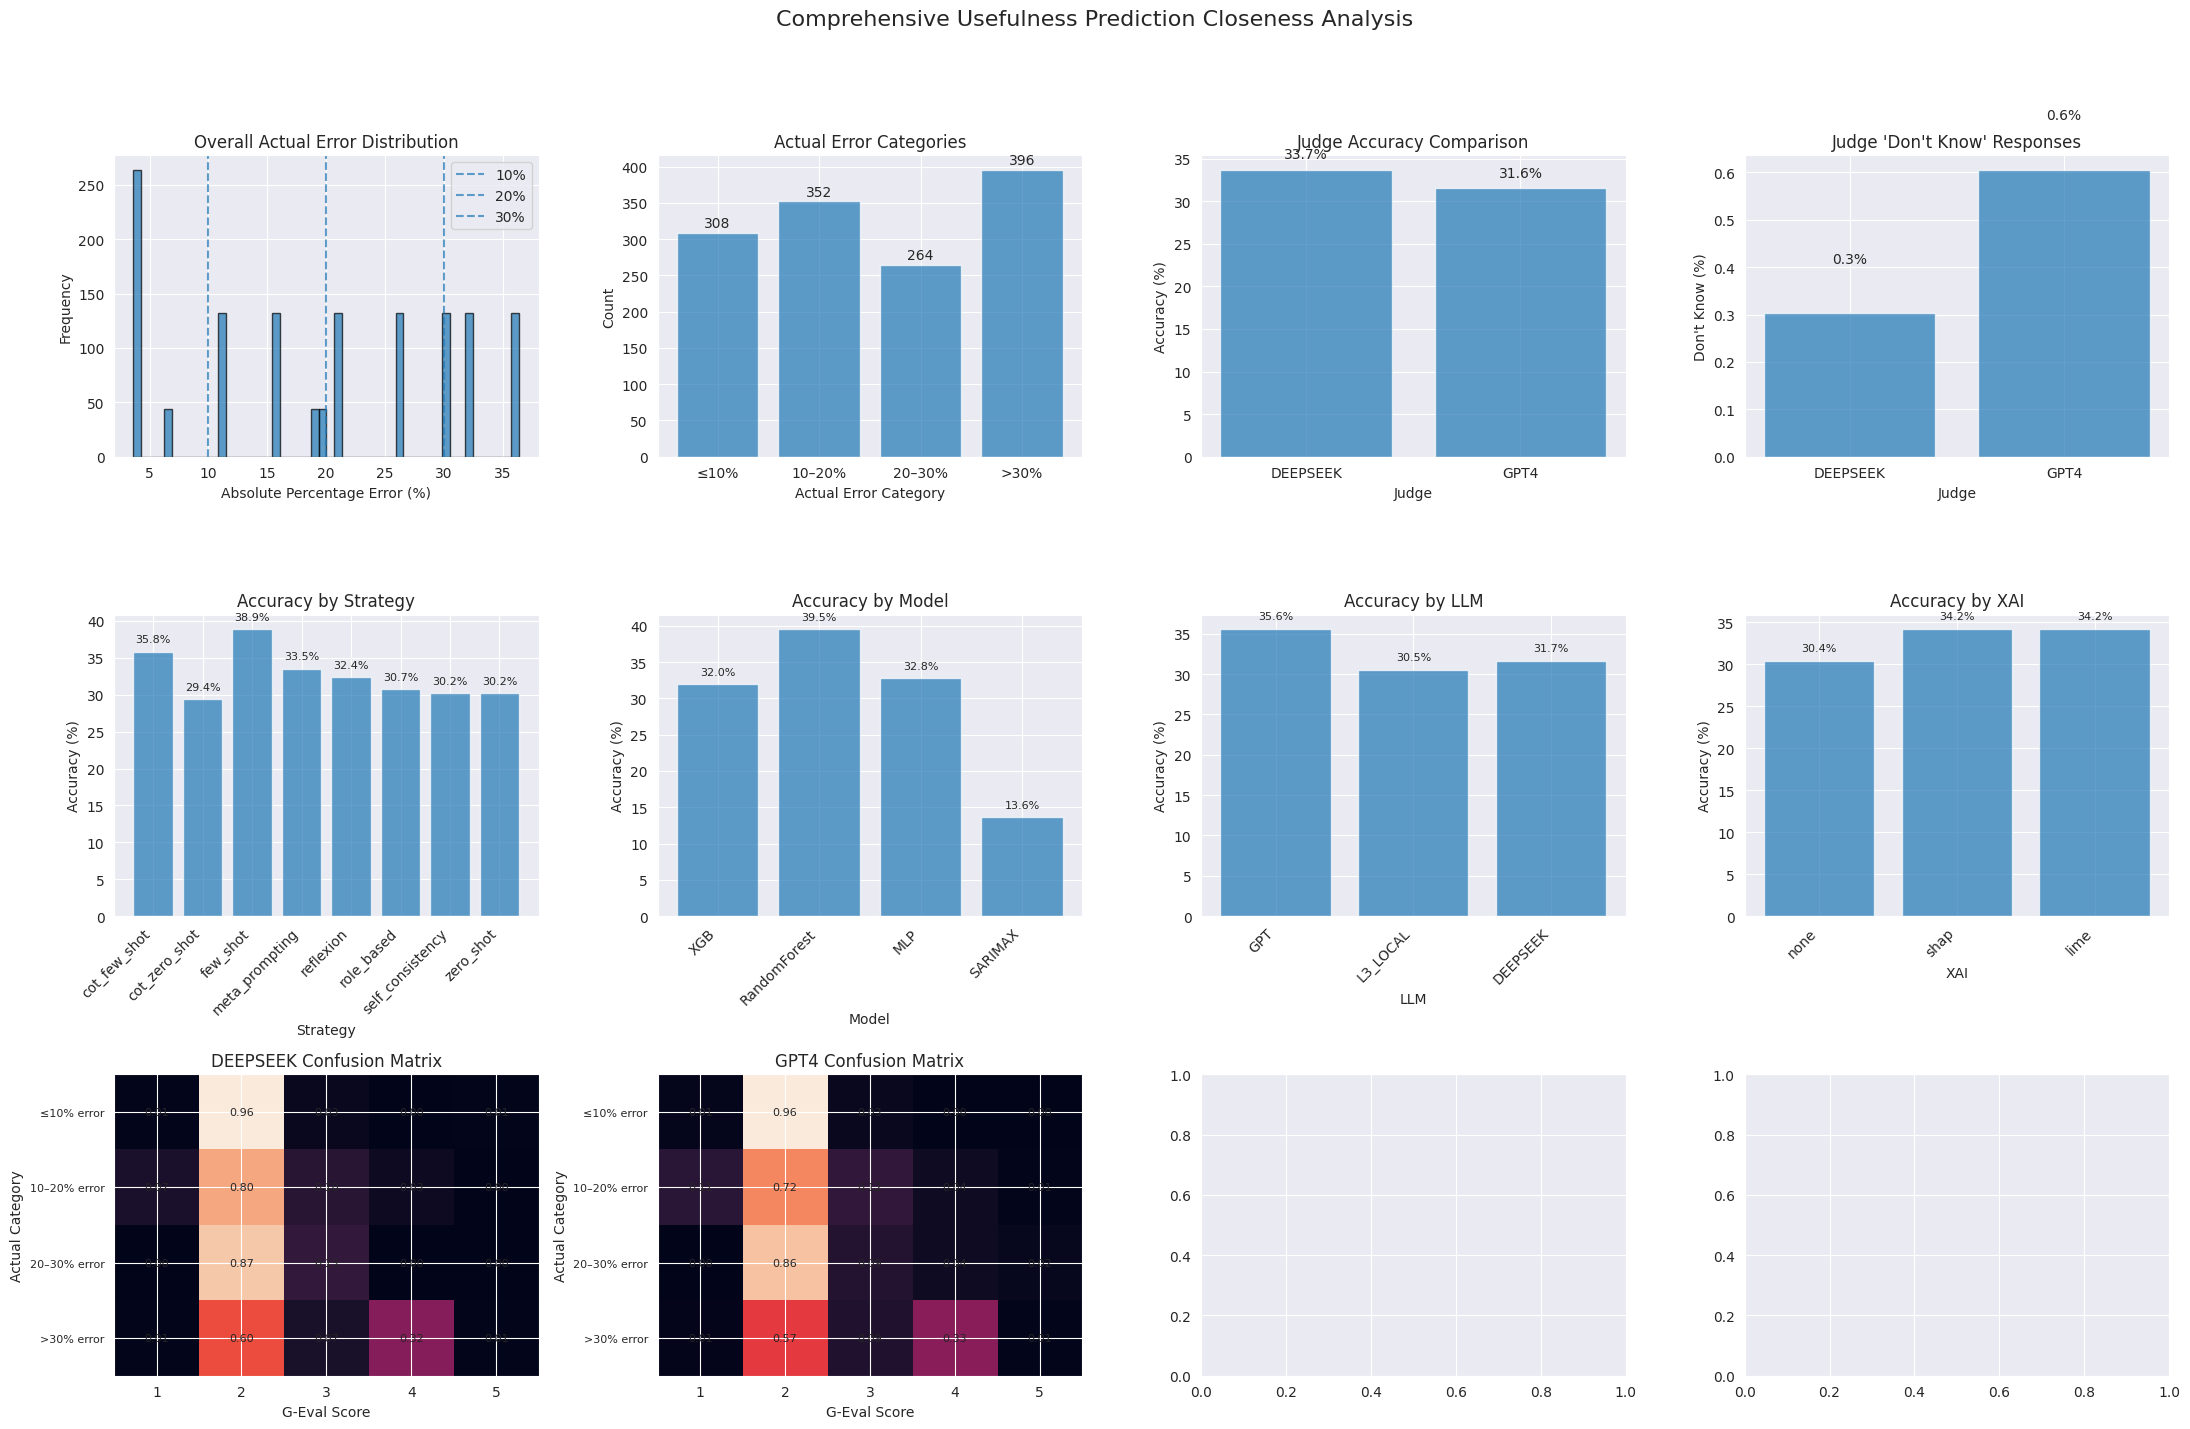


FINAL SUMMARY

📊 Overall Statistics:
   Total samples analyzed: 1320
   Judges analyzed: ['DEEPSEEK', 'GPT4']

🎯 Judge Performance Summary:
   DEEPSEEK:
     Samples: 660
     Accuracy: 33.7%
     Correlation: 0.381
     Don't know responses: 2 (0.3%)
   GPT4:
     Samples: 660
     Accuracy: 31.6%
     Correlation: 0.386
     Don't know responses: 4 (0.6%)

✅ Comprehensive usefulness prediction closeness analysis completed!
Analysis data shape: (1320, 70)
Judges analyzed: ['DEEPSEEK', 'GPT4']


In [26]:
# === COMPREHENSIVE USEFULNESS PREDICTION CLOSENESS SANITY CHECK ===
# This section analyzes the relationship between actual prediction errors (PctError)
# and how G-Eval judges scored the "usefulness_prediction_closeness" dimension
# Includes both judges, "don't know" analysis, and factor analysis

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


def analyze_usefulness_prediction_closeness_comprehensive(
        results_folder_path,
        save_plots=True,
        output_path=None
):
    """
    Comprehensive analysis of usefulness prediction closeness with both judges,
    don't-know analysis, and factor breakdowns.
    """

    if output_path is None:
        output_path = results_folder_path

    results_path = Path(results_folder_path)
    if not results_path.exists():
        print(f"ERROR: Results folder not found: {results_folder_path}")
        return

    print("\n" + "=" * 80)
    print("COMPREHENSIVE USEFULNESS PREDICTION CLOSENESS SANITY CHECK")
    print("=" * 80)
    print(f"Reading from: {results_folder_path}")

    # Load G-Eval results
    geval_files = list(results_path.glob("geval_*.csv"))
    if not geval_files:
        print("ERROR: No geval_*.csv files found in results folder")
        return

    print(f"Found G-Eval files: {[f.name for f in geval_files]}")

    # Load and combine all G-Eval results
    all_geval_data = []
    for file in geval_files:
        try:
            df = pd.read_csv(file)
            judge_name = file.stem.replace("geval_", "").upper()
            df["judge"] = judge_name
            all_geval_data.append(df)
            print(f"Loaded {len(df)} rows from {file.name}")
        except Exception as e:
            print(f"Error loading {file.name}: {e}")

    if not all_geval_data:
        print("ERROR: Could not load any G-Eval data")
        return

    # Combine all data
    combined_data = pd.concat(all_geval_data, ignore_index=True)
    print(f"Total combined rows: {len(combined_data)}")

    # Check which score columns are available for each judge
    geval_score_col = "eval_usefulness_prediction_closeness_g_eval_score"
    traditional_score_col = "eval_usefulness_prediction_closeness_traditional_score"

    print("\n=== CHECKING AVAILABLE SCORE COLUMNS ===")
    for judge in combined_data["judge"].unique():
        judge_data = combined_data[combined_data["judge"] == judge]
        geval_available = (
                geval_score_col in judge_data.columns
                and judge_data[geval_score_col].notna().any()
        )
        traditional_available = (
                traditional_score_col in judge_data.columns
                and judge_data[traditional_score_col].notna().any()
        )
        print(f"{judge} Judge:")
        print(f"  G-Eval probability scores available: {geval_available}")
        print(f"  Traditional discrete scores available: {traditional_available}")

        if geval_available:
            non_null_geval = judge_data[geval_score_col].notna().sum()
            print(f"    Non-null G-Eval scores: {non_null_geval}")
        if traditional_available:
            non_null_trad = judge_data[traditional_score_col].notna().sum()
            print(f"    Non-null traditional scores: {non_null_trad}")

    # Use traditional scores for analysis (discrete 1–5)
    score_col = traditional_score_col

    # Check required columns
    required_cols = ["PctError", score_col]
    missing_cols = [col for col in required_cols if col not in combined_data.columns]
    if missing_cols:
        print(f"ERROR: Missing required columns: {missing_cols}")
        return

    # Clean the data
    clean_data = combined_data.dropna(subset=["PctError", score_col]).copy()
    print(f"\nRows after removing missing values: {len(clean_data)}")

    # Remove extreme outliers for visualization
    extreme_outliers = np.abs(clean_data["PctError"]) > 1000
    print(f"Extreme outliers (>1000% error): {extreme_outliers.sum()}")

    analysis_data = clean_data.copy()
    viz_data = clean_data[np.abs(clean_data["PctError"]) <= 1000].copy()

    print("\n1. ACTUAL PERCENTAGE ERROR DISTRIBUTION")
    print(f"   Total samples: {len(analysis_data)}")
    print(f"   Mean absolute error: {np.abs(analysis_data['PctError']).mean():.2f}%")
    print(f"   Median absolute error: {np.abs(analysis_data['PctError']).median():.2f}%")
    print(f"   Std deviation: {analysis_data['PctError'].std():.2f}%")

    # Percentiles
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    print("   Percentiles of absolute error:")
    for p in percentiles:
        val = np.percentile(np.abs(analysis_data["PctError"]), p)
        print(f"     {p}th: {val:.2f}%")

    # Create error categories (4 categories for actual errors)
    def categorize_error(pct_error):
        """Categorize percentage error - 4 categories for actual errors"""
        if pd.isna(pct_error):
            return np.nan
        abs_error = abs(pct_error)
        if abs_error <= 10:
            return 1  # Very close (within ±10% error)
        elif abs_error <= 20:
            return 2  # Close (±10% to ±20% error)
        elif abs_error <= 30:
            return 3  # Somewhat off (±20% to ±30% error)
        else:
            return 4  # Far off (>±30% error)

    analysis_data["actual_error_category"] = analysis_data["PctError"].apply(categorize_error)
    viz_data["actual_error_category"] = viz_data["PctError"].apply(categorize_error)

    # Distribution of actual error categories
    error_cat_dist = analysis_data["actual_error_category"].value_counts().sort_index()
    print("\n2. ACTUAL ERROR CATEGORY DISTRIBUTION")
    category_labels = {
        1: "≤10% error",
        2: "10–20% error",
        3: "20–30% error",
        4: ">30% error",
    }
    for cat in [1, 2, 3, 4]:
        count = int(error_cat_dist.get(cat, 0))
        pct = count / len(analysis_data) * 100 if len(analysis_data) > 0 else 0.0
        print(f"   Category {cat} ({category_labels[cat]}): {count} samples ({pct:.1f}%)")

    # Analyze each judge separately
    judges = list(analysis_data["judge"].unique())
    print(f"\n3. JUDGES TO ANALYZE: {judges}")

    judge_results = {}

    for judge in judges:
        print("\n" + "=" * 60)
        print(f"ANALYZING JUDGE: {judge}")
        print("=" * 60)

        judge_data = analysis_data[analysis_data["judge"] == judge].copy()
        judge_data = judge_data.dropna(subset=["actual_error_category", score_col])

        if len(judge_data) == 0:
            print(f"   No valid data for {judge} judge")
            continue

        print(f"\n   {judge} Judge Statistics:")
        print(f"     Total valid assessments: {len(judge_data)}")

        # Score statistics
        usefulness_scores = judge_data[score_col].dropna()
        print(f"     Score range: {usefulness_scores.min():.0f} - {usefulness_scores.max():.0f}")
        print(f"     Mean score: {usefulness_scores.mean():.3f}")
        print(f"     Std deviation: {usefulness_scores.std():.3f}")

        # Score distribution including "don't know" analysis
        score_dist = usefulness_scores.value_counts().sort_index()
        print("\n     Score distribution:")
        geval_labels = {
            1: "Score 1 (Very close, ≤10%)",
            2: "Score 2 (Close, 10–20%)",
            3: "Score 3 (Somewhat off, 20–30%)",
            4: "Score 4 (Far off, >30%)",
            5: "Score 5 (Don't know)",
        }

        dont_know_count = 0
        for score in [1, 2, 3, 4, 5]:
            count = int(score_dist.get(score, 0))
            pct = count / len(usefulness_scores) * 100 if len(usefulness_scores) > 0 else 0
            label = geval_labels.get(score, f"Score {score}")
            print(f"       {label}: {count} ({pct:.1f}%)")
            if score == 5:
                dont_know_count = count

        print("\n     📊 DON'T KNOW ANALYSIS:")
        print(f"       Total 'don't know' responses: {dont_know_count}")
        print(f"       Percentage of 'don't know': {(dont_know_count / len(usefulness_scores) * 100):.1f}%")

        # Analyze what actual errors led to "don't know" responses
        if dont_know_count > 0:
            dont_know_data = judge_data[judge_data[score_col] == 5]
            print(f"       Actual errors for 'don't know' responses:")
            for _, row in dont_know_data.iterrows():
                actual_error = abs(row["PctError"])
                actual_cat = row["actual_error_category"]
                cat_label = category_labels.get(int(actual_cat), f"Cat {actual_cat}")
                print(f"         {actual_error:.1f}% error ({cat_label})")

        # Create confusion matrix
        confusion = pd.crosstab(
            judge_data["actual_error_category"],
            judge_data[score_col],
            margins=True,
            margins_name="Total",
        )
        print("\n     Confusion Matrix (Actual vs G-Eval Assessment):")
        print(confusion.to_string())

        # Calculate accuracy metrics (exclude "don't know" scores)
        valid_for_accuracy = judge_data[judge_data[score_col] <= 4].copy()
        accuracy = None
        categorical_corr = None

        if len(valid_for_accuracy) > 0:
            actual_cats = valid_for_accuracy["actual_error_category"].astype(int)
            geval_cats = valid_for_accuracy[score_col].astype(int)

            exact_matches = (actual_cats == geval_cats).sum()
            accuracy = exact_matches / len(valid_for_accuracy) * 100
            print(
                f"\n     Exact match accuracy (excluding 'don't know'): {exact_matches}/{len(valid_for_accuracy)} ({accuracy:.1f}%)")

            within_1 = (np.abs(actual_cats - geval_cats) <= 1).sum()
            within_1_acc = within_1 / len(valid_for_accuracy) * 100
            print(f"     Within-1-category accuracy: {within_1}/{len(valid_for_accuracy)} ({within_1_acc:.1f}%)")

            categorical_corr = actual_cats.corr(geval_cats)
            print(f"     Correlation (categorical, excluding 'don't know'): {categorical_corr:.3f}")

        # Mean G-Eval score by actual error category
        print("\n     Mean G-Eval scores by actual error category:")
        for category in sorted(judge_data["actual_error_category"].dropna().unique()):
            subset = judge_data[judge_data["actual_error_category"] == category]
            if len(subset) > 0:
                mean_score = subset[score_col].mean()
                std_score = subset[score_col].std()
                label = category_labels.get(int(category), f"Category {int(category)}")
                print(f"       {label}: Mean = {mean_score:.3f} ± {std_score:.3f} (n={len(subset)})")

        # Store results
        judge_results[judge] = {
            "data": judge_data,
            "confusion": confusion,
            "valid_for_accuracy": valid_for_accuracy,
            "accuracy": accuracy,
            "correlation": categorical_corr,
            "dont_know_count": dont_know_count,
            "dont_know_pct": (dont_know_count / len(usefulness_scores) * 100) if len(usefulness_scores) > 0 else 0,
        }

    # === FACTOR ANALYSIS ===
    print("\n" + "=" * 80)
    print("FACTOR ANALYSIS (Strategy, Model, LLM, XAI)")
    print("=" * 80)

    factors = ["Strategy", "Model", "LLM", "XAI"]

    for factor in factors:
        if factor not in analysis_data.columns:
            print(f"\nWARNING: Factor '{factor}' not found in data")
            continue

        print(f"\n📊 ANALYSIS BY {factor.upper()}")
        print("─" * 60)

        factor_values = analysis_data[factor].unique()
        print(f"   {factor} values: {list(factor_values)}")

        for judge in judges:
            judge_data = analysis_data[analysis_data["judge"] == judge]
            if len(judge_data) == 0:
                continue

            print(f"\n   {judge} Judge - {factor} Performance:")

            factor_stats = []
            for value in factor_values:
                subset = judge_data[judge_data[factor] == value]
                if len(subset) == 0:
                    continue

                # Calculate metrics for this factor value
                valid_subset = subset.dropna(subset=[score_col, "actual_error_category"])
                if len(valid_subset) == 0:
                    continue

                mean_score = valid_subset[score_col].mean()
                mean_actual_error = np.abs(valid_subset["PctError"]).mean()

                # Accuracy (excluding don't know)
                accuracy_subset = valid_subset[valid_subset[score_col] <= 4]
                if len(accuracy_subset) > 0:
                    exact_matches = (accuracy_subset["actual_error_category"] == accuracy_subset[score_col]).sum()
                    accuracy_val = exact_matches / len(accuracy_subset) * 100
                else:
                    accuracy_val = np.nan

                # Don't know percentage
                dont_know_count = (valid_subset[score_col] == 5).sum()
                dont_know_pct = (dont_know_count / len(valid_subset) * 100) if len(valid_subset) > 0 else 0

                factor_stats.append(
                    {
                        "value": value,
                        "n_samples": len(valid_subset),
                        "mean_geval_score": mean_score,
                        "mean_actual_error": mean_actual_error,
                        "accuracy": accuracy_val,
                        "dont_know_pct": dont_know_pct,
                    }
                )

                print(f"     {value}:")
                print(f"       Samples: {len(valid_subset)}")
                print(f"       Mean G-Eval score: {mean_score:.3f}")
                print(f"       Mean actual error: {mean_actual_error:.2f}%")
                if not np.isnan(accuracy_val):
                    print(f"       Accuracy: {accuracy_val:.1f}%")
                print(f"       Don't know: {dont_know_pct:.1f}%")

            # Create factor comparison DataFrame + correlations
            if factor_stats:
                factor_df = pd.DataFrame(factor_stats)

                # Find best/worst by accuracy (if defined)
                if factor_df["accuracy"].notna().any() and len(factor_df) > 1:
                    best_idx = factor_df["accuracy"].idxmax()
                    worst_idx = factor_df["accuracy"].idxmin()
                    best_accuracy = factor_df.loc[best_idx]
                    worst_accuracy = factor_df.loc[worst_idx]
                    print(
                        f"\n     📈 Best {factor} (accuracy): {best_accuracy['value']} ({best_accuracy['accuracy']:.1f}%)")
                    print(
                        f"     📉 Worst {factor} (accuracy): {worst_accuracy['value']} ({worst_accuracy['accuracy']:.1f}%)")

                print(f"\n     🔗 Correlation by {factor}:")
                for _, row in factor_df.iterrows():
                    subset = judge_data[judge_data[factor] == row["value"]]
                    valid_subset = subset.dropna(subset=[score_col, "actual_error_category"])
                    corr = np.nan
                    if len(valid_subset) > 1:
                        corr = valid_subset["actual_error_category"].corr(valid_subset[score_col])
                    print(f"       {row['value']}: r = {corr:.3f} (n={len(valid_subset)})")

    # === VISUALIZATION ===
    print("\n" + "=" * 60)
    print("CREATING COMPREHENSIVE VISUALIZATIONS")
    print("=" * 60)

    # Layout: 3 rows x 4 cols
    # Row 0: overall distributions & judge summaries
    # Row 1: factor plots (Strategy, Model, LLM, XAI)
    # Row 2: judge-specific confusion matrices (up to 4 judges)
    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    fig.suptitle("Comprehensive Usefulness Prediction Closeness Analysis", fontsize=16)

    # Plot 1: Overall actual error distribution
    axes[0, 0].hist(np.abs(viz_data["PctError"]), bins=50, alpha=0.7, edgecolor="black")
    axes[0, 0].axvline(10, linestyle="--", alpha=0.7, label="10%")
    axes[0, 0].axvline(20, linestyle="--", alpha=0.7, label="20%")
    axes[0, 0].axvline(30, linestyle="--", alpha=0.7, label="30%")
    axes[0, 0].set_xlabel("Absolute Percentage Error (%)")
    axes[0, 0].set_ylabel("Frequency")
    axes[0, 0].set_title("Overall Actual Error Distribution")
    axes[0, 0].legend()

    # Plot 2: Actual error categories
    error_dist = analysis_data["actual_error_category"].value_counts().sort_index()
    bars = axes[0, 1].bar(error_dist.index.astype(int), error_dist.values, alpha=0.7)
    axes[0, 1].set_xlabel("Actual Error Category")
    axes[0, 1].set_ylabel("Count")
    axes[0, 1].set_title("Actual Error Categories")
    axes[0, 1].set_xticks([1, 2, 3, 4])
    axes[0, 1].set_xticklabels(["≤10%", "10–20%", "20–30%", ">30%"])
    ymax = max(error_dist.values) if len(error_dist) else 0
    for bar, count in zip(bars, error_dist.values):
        axes[0, 1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.01 * ymax if ymax else 0.5),
            str(int(count)),
            ha="center",
            va="bottom",
        )

    # Plot 3: Judge comparison - accuracy
    judge_names = []
    accuracies = []
    dont_know_pcts = []

    for judge, results in judge_results.items():
        judge_names.append(judge)
        accuracies.append(results["accuracy"] if results["accuracy"] is not None else 0.0)
        dont_know_pcts.append(results["dont_know_pct"])

    x_pos = np.arange(len(judge_names))
    axes[0, 2].bar(x_pos, accuracies, alpha=0.7)
    axes[0, 2].set_xlabel("Judge")
    axes[0, 2].set_ylabel("Accuracy (%)")
    axes[0, 2].set_title("Judge Accuracy Comparison")
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels(judge_names, rotation=0)
    for i, acc in enumerate(accuracies):
        axes[0, 2].text(i, acc + 1, f"{acc:.1f}%", ha="center", va="bottom")

    # Plot 4: Judge comparison - don't know percentage
    axes[0, 3].bar(x_pos, dont_know_pcts, alpha=0.7)
    axes[0, 3].set_xlabel("Judge")
    axes[0, 3].set_ylabel("Don't Know (%)")
    axes[0, 3].set_title("Judge 'Don't Know' Responses")
    axes[0, 3].set_xticks(x_pos)
    axes[0, 3].set_xticklabels(judge_names, rotation=0)
    for i, pct in enumerate(dont_know_pcts):
        axes[0, 3].text(i, pct + 0.1, f"{pct:.1f}%", ha="center", va="bottom")

    # Row 1: Factor analysis visualizations (up to 4 factors)
    for idx, factor in enumerate(["Strategy", "Model", "LLM", "XAI"]):
        ax = axes[1, idx]
        if factor not in analysis_data.columns:
            ax.axis("off")
            ax.set_title(f"{factor} (not found)")
            continue

        factor_accuracies = []
        factor_labels = []

        for value in analysis_data[factor].unique():
            subset = analysis_data[analysis_data[factor] == value]
            if len(subset) == 0:
                continue
            valid_subset = subset.dropna(subset=[score_col, "actual_error_category"])
            accuracy_subset = valid_subset[valid_subset[score_col] <= 4]
            if len(accuracy_subset) > 0:
                exact_matches = (accuracy_subset["actual_error_category"] == accuracy_subset[score_col]).sum()
                acc_val = exact_matches / len(accuracy_subset) * 100
                factor_accuracies.append(acc_val)
                factor_labels.append(str(value))

        if factor_accuracies:
            bars = ax.bar(range(len(factor_labels)), factor_accuracies, alpha=0.7)
            ax.set_xlabel(factor)
            ax.set_ylabel("Accuracy (%)")
            ax.set_title(f"Accuracy by {factor}")
            ax.set_xticks(range(len(factor_labels)))
            ax.set_xticklabels(factor_labels, rotation=45, ha="right")
            for bar, acc in zip(bars, factor_accuracies):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{acc:.1f}%", ha="center",
                        va="bottom", fontsize=8)
        else:
            ax.axis("off")
            ax.set_title(f"{factor} (no data)")

    # Row 2: Judge-specific confusion matrices (up to 4 judges)
    plot_positions = [(2, 0), (2, 1), (2, 2), (2, 3)]
    for idx, (judge, results) in enumerate(judge_results.items()):
        if idx >= 4:
            break
        row_idx, col_idx = plot_positions[idx]
        ax = axes[row_idx, col_idx]

        judge_data = results["data"]
        confusion_matrix = pd.crosstab(
            judge_data["actual_error_category"],
            judge_data[score_col]
        )

        # Normalize confusion matrix by row
        confusion_norm = confusion_matrix.div(confusion_matrix.sum(axis=1), axis=0).fillna(0)

        im = ax.imshow(confusion_norm.values, aspect="auto")
        # Add text annotations
        for i in range(len(confusion_norm.index)):
            for j in range(len(confusion_norm.columns)):
                ax.text(j, i, f"{confusion_norm.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

        ax.set_xlabel("G-Eval Score")
        ax.set_ylabel("Actual Category")
        ax.set_title(f"{judge} Confusion Matrix")

        # Set tick labels
        ax.set_xticks(range(len(confusion_norm.columns)))
        ax.set_xticklabels([f"{int(col)}" for col in confusion_norm.columns])
        ax.set_yticks(range(len(confusion_norm.index)))
        ax.set_yticklabels([category_labels.get(int(idx_), "") for idx_ in confusion_norm.index], fontsize=8)

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_plots:
        plot_path = Path(output_path) / "usefulness_comprehensive_analysis.png"
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"\nComprehensive plot saved to: {plot_path}")
    plt.show()

    # === FINAL SUMMARY ===
    print("\n" + "=" * 80)
    print("FINAL SUMMARY")
    print("=" * 80)

    print("\n📊 Overall Statistics:")
    print(f"   Total samples analyzed: {len(analysis_data)}")
    print(f"   Judges analyzed: {list(judge_results.keys())}")

    print("\n🎯 Judge Performance Summary:")
    for judge, results in judge_results.items():
        print(f"   {judge}:")
        print(f"     Samples: {len(results['data'])}")
        if results["accuracy"] is not None:
            print(f"     Accuracy: {results['accuracy']:.1f}%")
        if results["correlation"] is not None:
            print(f"     Correlation: {results['correlation']:.3f}")
        print(f"     Don't know responses: {results['dont_know_count']} ({results['dont_know_pct']:.1f}%)")

    return analysis_data, judge_results



results_folder = "forsetzung_results/20250813_135743"

try:
    analysis_data, judge_results = analyze_usefulness_prediction_closeness_comprehensive(
        results_folder_path=results_folder,
        save_plots=True,
        output_path=results_folder
    )

    print("\n✅ Comprehensive usefulness prediction closeness analysis completed!")
    if analysis_data is not None:
        print(f"Analysis data shape: {analysis_data.shape}")
        print(f"Judges analyzed: {list(judge_results.keys())}")

except Exception as e:
    print(f"\n❌ Error in comprehensive analysis: {e}")
    import traceback

    traceback.print_exc()



######################################################################
Judge: DEEPSEEK
######################################################################

Raw confusion matrix (rows=actual error cat, cols=scores 1–5):
eval_usefulness_prediction_closeness_traditional_score   1    2   3   4  5
actual_error_category                                                     
1                                                        1  148   4   0  1
2                                                       12  140  18   6  0
3                                                        0  115  17   0  0
4                                                        1  119  13  64  1


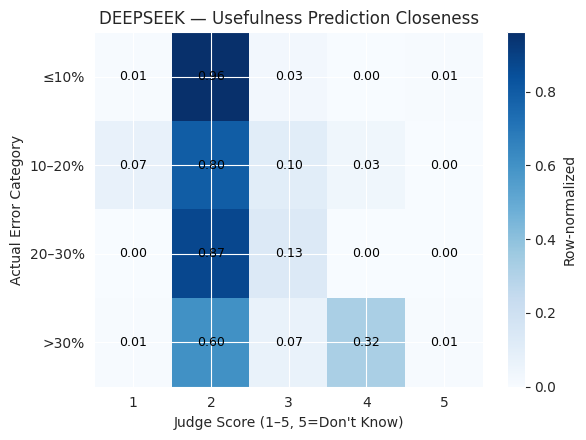


######################################################################
Judge: GPT4
######################################################################

Raw confusion matrix (rows=actual error cat, cols=scores 1–5):
eval_usefulness_prediction_closeness_traditional_score   1    2   3   4  5
actual_error_category                                                     
1                                                        2  148   4   0  0
2                                                       19  127  22   7  1
3                                                        0  113  12   5  2
4                                                        2  112  17  66  1


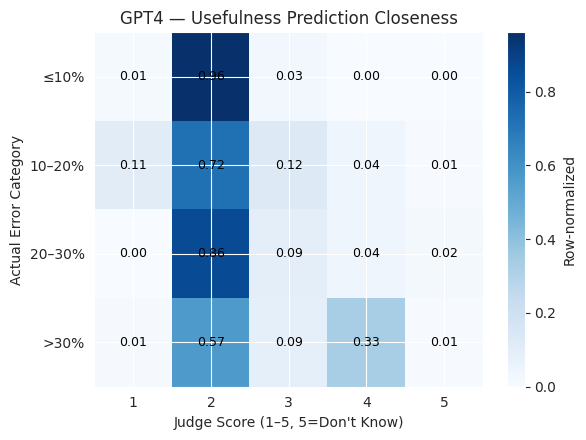

In [28]:
# Confusion matrix for usefulness_prediction_closeness
# Across judges (no factor breakdowns)
#
# Rows = actual error categories (1–4)
# Cols = judge-assigned scores (1–5, where 5 = "don't know")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_FOLDER = "forsetzung_results/20250813_135743"  # <-- set this to your folder path


def _categorize_error(pct_error: float):
    """Categorize into 4 bins for absolute % error."""
    if pd.isna(pct_error):
        return np.nan
    abs_err = abs(pct_error)
    if abs_err <= 10:
        return 1
    elif abs_err <= 20:
        return 2
    elif abs_err <= 30:
        return 3
    else:
        return 4


def load_data(results_folder: str):
    folder = Path(results_folder)
    files = list(folder.glob("geval_*.csv"))
    if not files:
        raise FileNotFoundError(f"No 'geval_*.csv' found in {results_folder}")

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["judge"] = f.stem.replace("geval_", "").upper()
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)

    if "PctError" not in combined.columns:
        raise KeyError("Missing 'PctError' in data.")

    combined["actual_error_category"] = combined["PctError"].apply(_categorize_error)
    return combined


def confusion_for_judge(df: pd.DataFrame, score_col: str, judge: str):
    sub = df[df["judge"] == judge].dropna(subset=["actual_error_category", score_col]).copy()
    sub["actual_error_category"] = sub["actual_error_category"].astype(int)
    sub[score_col] = sub[score_col].astype(int)

    conf = pd.crosstab(sub["actual_error_category"], sub[score_col], dropna=False)
    conf = conf.reindex(index=[1, 2, 3, 4], fill_value=0)

    # ensure columns 1–5 exist
    for c in [1, 2, 3, 4, 5]:
        if c not in conf.columns:
            conf[c] = 0
    conf = conf[[1, 2, 3, 4, 5]]
    return conf


def plot_confusion(conf: pd.DataFrame, judge: str, title: str):
    # Row-normalize
    norm = conf.div(conf.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    data = norm.values

    fig, ax = plt.subplots(figsize=(6, 4.5))
    im = ax.imshow(data, aspect="auto", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Judge Score (1–5, 5=Don't Know)")
    ax.set_ylabel("Actual Error Category")

    ax.set_xticks(range(conf.shape[1]))
    ax.set_xticklabels(conf.columns)
    ax.set_yticks(range(conf.shape[0]))
    ax.set_yticklabels(["≤10%", "10–20%", "20–30%", ">30%"])

    # Annotate
    for i in range(conf.shape[0]):
        for j in range(conf.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row-normalized")
    plt.tight_layout()
    plt.show()


# === Run ===
combined = load_data(RESULTS_FOLDER)
score_col = "eval_usefulness_prediction_closeness_traditional_score"

if score_col not in combined.columns:
    raise KeyError(f"Column '{score_col}' not found in data.")

for judge in sorted(combined["judge"].unique()):
    print("\n" + "#" * 70)
    print(f"Judge: {judge}")
    print("#" * 70)

    conf = confusion_for_judge(combined, score_col, judge)
    print("\nRaw confusion matrix (rows=actual error cat, cols=scores 1–5):")
    print(conf.to_string())

    plot_confusion(conf, judge, f"{judge} — Usefulness Prediction Closeness")



🚀 Running Usefulness—Prediction Closeness with MINIMAL CONTEXT (Prediction + Model), NO EXPLANATION
Using all 660 rows

USEFULNESS — PREDICTION CLOSENESS :: MINIMAL CONTEXT (Prediction + Model), NO EXPLANATION :: GPT-4

GPT-4 finished: 1477.85s (avg 2.24s/row)

USEFULNESS — PREDICTION CLOSENESS :: MINIMAL CONTEXT (Prediction + Model), NO EXPLANATION :: DeepSeek

DeepSeek finished: 2581.06s (avg 3.91s/row)

SUMMARY — Don't-know rates and confusion matrices (MINIMAL CONTEXT)

--- DeepSeek ---
  Total evals: 660
  'Don't know' (5): 660/660  (100.0%)

  Confusion matrix (rows=Actual error cat, cols=Score 1–5):
score_traditional      1  2  3  4    5
actual_error_category                 
1                      0  0  0  0  154
2                      0  0  0  0  176
3                      0  0  0  0  132
4                      0  0  0  0  198


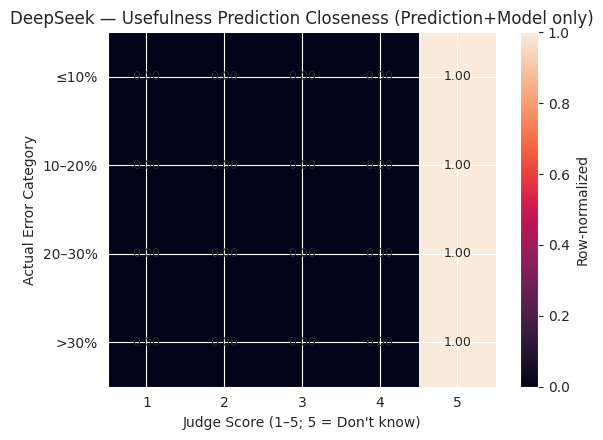


--- GPT-4 ---
  Total evals: 660
  'Don't know' (5): 660/660  (100.0%)

  Confusion matrix (rows=Actual error cat, cols=Score 1–5):
score_traditional      1  2  3  4    5
actual_error_category                 
1                      0  0  0  0  154
2                      0  0  0  0  176
3                      0  0  0  0  132
4                      0  0  0  0  198


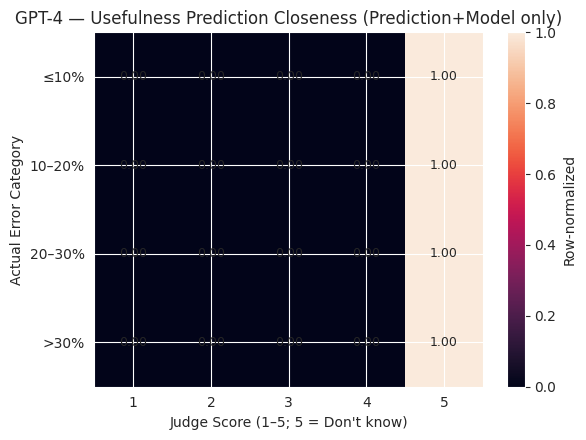

In [38]:
# === SANITY CHECK: Usefulness Prediction Closeness with MINIMAL CONTEXT (Prediction + Model, NO EXPLANATION) ===
# For each row, judges see ONLY:
#   Context:
#     Prediction=<value>; Model=<name>
# There is NO Explanation sent.
#
# We print EXACTLY what we send (system + user messages) and EXACTLY what the LLM replies.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import re

# ---------- Prompt for the minimal-info setting (Prediction + Model only) ----------
USEFULNESS_PREDICTION_CLOSENESS_NOINFO_PROMPT = """
You are a NON-TECHNICAL USER evaluating how close a forecast prediction is to the true value.

You have NO background in machine learning or statistics. You just want to know if the predicted value is likely to be close to the actual outcome.

Context: Time series forecast with prediction value.

Evaluation Criteria:
PREDICTION CLOSENESS (1-5): How close is the predicted value to the true value?
- 1: Very close (within ±10% error)
- 2: Close (±10% to ±20% error)
- 3: Somewhat off (±20% to ±30% error)
- 4: Far off (more than ±30% error)
- 5: Don't know / Cannot determine from the explanation

Chain of Thought Evaluation Steps:
1. Identify any signals in the explanation that indicate expected error or confidence.
2. Check whether concrete comparisons or references support an error estimate.
3. Translate those cues into an approximate percentage error band.
4. If the explanation lacks sufficient information to estimate closeness, choose 5 (Don't know).
5. Assign a score using the 1–5 scale above.

Please think through each step, **then on a new line output only**

SCORE: <1-5>
""".strip()


# ---- Helpers ----
def _extract_score_safely(text: str):
    if not isinstance(text, str) or not text.strip():
        return None
    m = re.search(r"SCORE:\s*(\d+)", text, re.IGNORECASE)
    if m:
        v = int(m.group(1))
        return v if 1 <= v <= 5 else None
    tail = re.search(r"(\d+)\s*$", text.strip())
    if tail:
        v = int(tail.group(1))
        return v if 1 <= v <= 5 else None
    return None


def _actual_cat(pct_error):
    if pd.isna(pct_error):
        return None
    e = abs(float(pct_error))
    if e <= 10: return 1
    if e <= 20: return 2
    if e <= 30: return 3
    return 4


def _confusion_df(df: pd.DataFrame, score_col: str, judge_name: str) -> pd.DataFrame:
    sub = df[df["judge"] == judge_name].dropna(subset=["actual_error_category", score_col]).copy()
    if sub.empty:
        return pd.DataFrame(index=[1, 2, 3, 4], columns=[1, 2, 3, 4, 5]).fillna(0).astype(int)
    sub["actual_error_category"] = sub["actual_error_category"].astype(int)
    sub[score_col] = sub[score_col].astype(int)
    conf = pd.crosstab(sub["actual_error_category"], sub[score_col], dropna=False)
    conf = conf.reindex(index=[1, 2, 3, 4], fill_value=0)
    for c in [1, 2, 3, 4, 5]:
        if c not in conf.columns:
            conf[c] = 0
    return conf[[1, 2, 3, 4, 5]].astype(int)


def _plot_confusion(conf: pd.DataFrame, title: str):
    norm = conf.div(conf.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    data = norm.values
    fig, ax = plt.subplots(figsize=(6, 4.5))
    im = ax.imshow(data, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Judge Score (1–5; 5 = Don't know)")
    ax.set_ylabel("Actual Error Category")
    ax.set_xticks(range(conf.shape[1]));
    ax.set_xticklabels(conf.columns)
    ax.set_yticks(range(conf.shape[0]));
    ax.set_yticklabels(["≤10%", "10–20%", "20–30%", ">30%"])
    for i in range(conf.shape[0]):
        for j in range(conf.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=9)
    cbar = fig.colorbar(im, ax=ax);
    cbar.set_label("Row-normalized")
    plt.tight_layout();
    plt.show()


# ---- Low-level senders (to control message format exactly) ----
def _send_to_gpt_no_expl(judge, system_prompt: str, user_message: str, use_logprobs: bool):
    """Direct call to GPTJudge client with our exact messages (no 'Explanation:' label)."""
    try:
        kwargs = dict(
            model=judge.deployment,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message}
            ],
            temperature=judge.temperature
        )
        if use_logprobs:
            kwargs.update(dict(logprobs=True, top_logprobs=5))
        resp = judge.client.chat.completions.create(**kwargs)
        raw = resp.choices[0].message.content
        g_eval = None
        if use_logprobs and resp.choices[0].logprobs and resp.choices[0].logprobs.content:
            # reuse judge's internal method for prob-weighted score
            g_eval = judge._calculate_g_eval_score(resp.choices[0].logprobs.content, ["1", "2", "3", "4", "5"])
        tokens = {
            "prompt_tokens": getattr(resp.usage, "prompt_tokens", 0) if hasattr(resp, "usage") else 0,
            "completion_tokens": getattr(resp.usage, "completion_tokens", 0) if hasattr(resp, "usage") else 0,
            "total_tokens": getattr(resp.usage, "total_tokens", 0) if hasattr(resp, "usage") else 0,
        }
        return {"raw_response": raw, "g_eval_score": g_eval, "tokens": tokens, "success": True}
    except Exception as e:
        return {"raw_response": f"ERROR: {e}", "g_eval_score": None, "tokens": {"total_tokens": 0}, "success": False}


def _send_to_deepseek_no_expl(judge, system_prompt: str, user_message: str):
    """Direct call to DeepSeekJudge client with our exact messages (no 'Explanation:' label)."""
    try:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message}
        ]
        resp = judge.client.invoke(messages)
        raw = resp.content
        # naive token estimate using your util if present
        try:
            total_tokens = count_tokens(system_prompt + user_message) + count_tokens(raw)
        except Exception:
            total_tokens = 0
        tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": total_tokens}
        return {"raw_response": raw, "g_eval_score": None, "tokens": tokens, "success": True}
    except Exception as e:
        return {"raw_response": f"ERROR: {e}", "g_eval_score": None, "tokens": {"total_tokens": 0}, "success": False}


# ---- Runner ----
def run_usefulness_closeness_minctx(
        df: pd.DataFrame,
        judges,
        prompt: str,
        save_csv: bool = True,
        out_dir: Path = Path("./"),
        max_rows: int | None = None,
        sleep_s: float = 0.5,
        verbose: bool = True,
        MAX_SHOW_CHARS: int | None = None  # None = print full messages/responses
) -> pd.DataFrame:
    if max_rows is not None and max_rows < len(df):
        work = df.sample(max_rows, random_state=42).reset_index(drop=True)
        print(f"Using a sample of {len(work)} rows (of {len(df)})")
    else:
        work = df.reset_index(drop=True)
        print(f"Using all {len(work)} rows")

    work = work.copy()
    work["actual_error_category"] = work["PctError"].apply(_actual_cat)

    def _clip(s: str) -> str:
        if MAX_SHOW_CHARS is None or not isinstance(s, str):
            return s
        return s if len(s) <= MAX_SHOW_CHARS else s[
                                                      :MAX_SHOW_CHARS] + f"\n[… clipped {len(s) - MAX_SHOW_CHARS} chars …]"

    rows = []
    for j in judges:
        print("\n" + "=" * 60)
        print(f"USEFULNESS — PREDICTION CLOSENESS :: MINIMAL CONTEXT (Prediction + Model), NO EXPLANATION :: {j.name}")
        print("=" * 60)
        j.reset_tracking()
        t0 = time.time()

        for i, r in work.iterrows():
            # Build minimal context: Prediction + Model
            context = f"Prediction={r.get('Prediction', 'N/A')}; Model={r.get('Model', 'N/A')}"

            # Exact messages we will send
            system_msg = prompt
            user_msg = f"Context:\n{context}"  # ⟵ EXACT — no 'Explanation:' block

            if verbose:
                print("\n" + "-" * 60)
                print(f"[{j.name}] Row {i} — SYSTEM PROMPT (exact)")
                print(_clip(system_msg) if system_msg else "(empty)")
                print(f"\n[{j.name}] Row {i} — USER MESSAGE (exact)")
                print(_clip(user_msg) if user_msg else "(empty)")
                print("-" * 60)

            # Send with exact formatting (no Explanation)
            if hasattr(j, "deployment"):  # GPTJudge
                res = _send_to_gpt_no_expl(j, system_msg, user_msg, use_logprobs=True)
            else:  # DeepSeekJudge
                res = _send_to_deepseek_no_expl(j, system_msg, user_msg)

            raw = res.get("raw_response", "")
            score = _extract_score_safely(raw)
            g_eval = res.get("g_eval_score")

            if verbose:
                print(f"[{j.name}] Row {i} — RAW RESPONSE (exact)")
                print(_clip(raw) if raw else "(empty response)")
                print(f"[{j.name}] Row {i} — Parsed SCORE: {score}")
                print("-" * 60)

            rows.append({
                "row_index": i,
                "judge": j.name,
                "Strategy": r.get("Strategy"),
                "LLM": r.get("LLM"),
                "Model": r.get("Model"),
                "XAI": r.get("XAI"),
                "Prediction": r.get("Prediction"),
                "TrueValue": r.get("TrueValue"),
                "PctError": r.get("PctError"),
                "actual_error_category": r.get("actual_error_category"),
                "score_traditional": score,
                "score_g_eval": g_eval,
                "raw_response": raw,
                "sent_system_prompt": system_msg,
                "sent_user_message": user_msg,
            })

            time.sleep(sleep_s)

        elapsed = time.time() - t0
        print(f"\n{j.name} finished: {elapsed:.2f}s "
              f"(avg {elapsed / len(work):.2f}s/row)")

    results = pd.DataFrame(rows)

    # --- per-judge summaries ---
    print("\n" + "=" * 80)
    print("SUMMARY — Don't-know rates and confusion matrices (MINIMAL CONTEXT)")
    print("=" * 80)

    results["is_dont_know"] = results["score_traditional"].eq(5)

    for jname in sorted(results["judge"].dropna().unique()):
        jdf = results[results["judge"] == jname].copy()
        total = len(jdf)
        dk = int(jdf["is_dont_know"].sum())
        dk_pct = (dk / total * 100) if total else 0.0
        print(f"\n--- {jname} ---")
        print(f"  Total evals: {total}")
        print(f"  'Don't know' (5): {dk}/{total}  ({dk_pct:.1f}%)")

        conf = _confusion_df(results, "score_traditional", jname)
        print("\n  Confusion matrix (rows=Actual error cat, cols=Score 1–5):")
        print(conf.to_string())

        _plot_confusion(conf, f"{jname} — Usefulness Prediction Closeness (Prediction+Model only)")

    # Save results
    if save_csv:
        ts = time.strftime("%Y%m%d_%H%M%S")
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"usefulness_minctx_{ts}.csv"
        results.to_csv(out_path, index=False)
        print(f"\n💾 Saved results to: {out_path}")

    return results


# ---- Configs for this run ----
JUDGES_TO_RUN = [gpt_judge, deepseek_judge]  # keep your judges
MAX_ROWS = None  # set None to use all df_sample
SAVE_CSV = False
OUTPUT_DIR = Path(EVALUATION_OUTPUT_PATH)
SLEEP = CONFIG.get("SLEEP_BETWEEN_CALLS", 0.5)

# ---- RUN IT ----
print("\n🚀 Running Usefulness—Prediction Closeness with MINIMAL CONTEXT (Prediction + Model), NO EXPLANATION")
usefulness_minctx_results = run_usefulness_closeness_minctx(
    df_sample,
    judges=JUDGES_TO_RUN,
    prompt=USEFULNESS_PREDICTION_CLOSENESS_NOINFO_PROMPT,
    save_csv=SAVE_CSV,
    out_dir=OUTPUT_DIR,
    max_rows=MAX_ROWS,
    sleep_s=SLEEP,
    verbose=False,  # prints EXACT messages and responses
    MAX_SHOW_CHARS=None  # set to an int to clip long outputs
)
